# Generate 6-node networks of varying densities/signs

Generates the 5 unique 6-gene connectivity matrices needed for the OFAT
(one-factor-at-a-time) benchmarking design:

    - center:    density=9 edges, sign_ratio=0.5 (shared by both sweeps)
    - density=5: sign_ratio held at 0.5 (sparse)
    - density=17: sign_ratio held at 0.5 (dense)
    - sign=0.0:  density held at 9 (all-repressing)
    - sign=1.0:  density held at 9 (all-activating)

Does NOT include the linear-chain baseline (5 edges, already generated
separately). Matrix convention: matrix[i, j] != 0 means gene i regulates
gene j (row regulates column); +1 = activation, -1 = repression. This
matches read_input_matrix's expected format (comma-separated integers).

Each matrix is saved as a .txt file in the output folder, and a manifest
CSV records the design parameters for every generated network.


In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
output_folder = "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep_final/"
os.makedirs(output_folder, exist_ok=True)

In [3]:
def is_weakly_connected(matrix):
    """
    Checks whether the underlying undirected graph of a directed connectivity
    matrix is connected (every gene reachable from every other, ignoring
    edge direction and sign).

    Args:
        matrix (np.ndarray): n_genes x n_genes connectivity matrix.

    Returns:
        bool: True if the graph is weakly connected.
    """
    n = matrix.shape[0]
    adj = (matrix != 0) | (matrix != 0).T
    visited = np.zeros(n, dtype=bool)
    stack = [0]
    visited[0] = True
    while stack:
        node = stack.pop()
        neighbors = np.where(adj[node])[0]
        for nb in neighbors:
            if not visited[nb]:
                visited[nb] = True
                stack.append(nb)
    return visited.all()

def validate_connectivity_matrix(connectivity_matrix):
    """
    Validates that connectivity_matrix is square and has only one of 1,0 or -1.

    Args:
        connectivity_matrix (np.ndarray): Matrix to validate.

    Returns:
        bool: True if valid.

    Raises:
        ValueError: If the matrix is not square or contains values other than 1,0, and -1.
    """
    if connectivity_matrix.ndim != 2 or connectivity_matrix.shape[0] != connectivity_matrix.shape[1]:
        raise ValueError(f"connectivity_matrix must be square, got shape {connectivity_matrix.shape}")
    if not np.isin(connectivity_matrix, [1, 0, -1]).all():
        raise ValueError("connectivity_matrix must strictly contain only 1, 0, or -1")
    return True


def generate_random_grn_matrix(n_genes, n_edges, frac_positive, rng,
                               require_connected=True, max_attempts=200):
    """
    Generates a single random directed connectivity matrix with no self-loops.

    Args:
        n_genes (int): Number of genes (matrix will be n_genes x n_genes).
        n_edges (int): Exact number of regulatory edges to place. Must be
                       >= n_genes - 1 if require_connected is True.
        frac_positive (float): Target fraction of edges that are activating
                               (positive). Remaining edges are repressing.
        rng (np.random.Generator): Random number generator for reproducibility.
        require_connected (bool): If True, resample until the underlying
                                  undirected graph is weakly connected.
        max_attempts (int): Max resampling attempts before raising an error.

    Returns:
        np.ndarray: n_genes x n_genes connectivity matrix with values in {-1, 0, +1}.
    """
    min_edges = n_genes - 1
    if require_connected and n_edges < min_edges:
        raise ValueError(f"n_edges={n_edges} is below the minimum of {min_edges} "
                         f"required for a connected {n_genes}-gene network")

    all_positions = [(i, j) for i in range(n_genes) for j in range(n_genes) if i != j]
    max_edges = len(all_positions)
    if n_edges > max_edges:
        raise ValueError(f"n_edges={n_edges} exceeds max possible edges {max_edges}")

    for attempt in range(max_attempts):
        chosen_idx = rng.choice(max_edges, size=n_edges, replace=False)
        chosen_positions = [all_positions[k] for k in chosen_idx]

        n_pos = int(round(n_edges * frac_positive))
        signs = np.array([1] * n_pos + [-1] * (n_edges - n_pos))
        rng.shuffle(signs)

        matrix = np.zeros((n_genes, n_genes), dtype=int)
        for (i, j), sign in zip(chosen_positions, signs):
            matrix[i, j] = sign

        if not require_connected or is_weakly_connected(matrix):
            return matrix

    raise RuntimeError(f"Could not generate a connected {n_genes}-gene network with "
                       f"{n_edges} edges after {max_attempts} attempts")

import networkx as nx
from networkx.algorithms.isomorphism import DiGraphMatcher

def matrix_to_digraph(matrix):
    """
    Converts a signed connectivity matrix into a networkx DiGraph with edge
    sign stored as an attribute, for isomorphism comparison.

    Args:
        matrix (np.ndarray): n_genes x n_genes connectivity matrix.

    Returns:
        nx.DiGraph: Directed graph with 'sign' edge attributes.
    """
    G = nx.DiGraph()
    G.add_nodes_from(range(matrix.shape[0]))
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if matrix[i, j] != 0:
                G.add_edge(i, j, sign=int(np.sign(matrix[i, j])))
    return G


def is_isomorphic_to_any(matrix, existing_graphs, match_signs=True):
    """
    Checks whether a candidate matrix is graph-isomorphic to any graph
    already in existing_graphs (structure-only, or structure+sign).

    Args:
        matrix (np.ndarray): Candidate connectivity matrix.
        existing_graphs (list of nx.DiGraph): Previously accepted graphs.
        match_signs (bool): If True, treat two graphs as isomorphic only if
                            edge signs also match under some node relabeling
                            (stricter). If False, structure-only (ignores
                            activator/repressor identity).

    Returns:
        bool: True if isomorphic to at least one existing graph.
    """
    candidate = matrix_to_digraph(matrix)
    for G in existing_graphs:
        if match_signs:
            em = lambda e1, e2: e1["sign"] == e2["sign"]
            matcher = DiGraphMatcher(candidate, G, edge_match=em)
        else:
            matcher = DiGraphMatcher(candidate, G)
        if matcher.is_isomorphic():
            return True
    return False


def generate_ofat_sweep_topologies(n_genes=6,
                                   center=(9, 0.5),
                                   density_levels=(5, 17),
                                   sign_levels=(0.0, 1.0),
                                   n_topology_replicates=3,
                                   require_connected=True,
                                   output_folder="./grn_networks",
                                   seed=0):
    """
    Generates n_topology_replicates DISTINCT random topologies for each cell
    of a two-factor OFAT sweep (density and sign_ratio), sharing one center
    cell between both sweeps. Does NOT include the separately-established
    linear baseline.
 
    Args:
        n_genes (int): Number of genes per network.
        center (tuple): (edge_count, sign_ratio) for the shared center cell,
                        used as the fixed point for both sweeps.
        density_levels (tuple of int): The 2 non-center edge counts to sweep,
                                       sign_ratio held at center[1].
        sign_levels (tuple of float): The 2 non-center sign ratios to sweep,
                                      edge_count held at center[0].
        n_topology_replicates (int): Number of distinct random topologies to
                                     generate per cell (e.g. 3 gives 3
                                     independently-sampled networks sharing
                                     the same edge_count/sign_ratio, not 3
                                     reruns of the same matrix).
        require_connected (bool): Passed to generate_random_grn_matrix.
        output_folder (str): Output directory for matrices (.txt) and manifest.
        seed (int): Base seed for topology generation.
 
    Returns:
        pd.DataFrame: Manifest with one row per topology, a 'cell' column
                     ('center', 'density', 'sign_ratio') marking sweep
                     membership, a 'topology_replicate' index, and the
                     connectivity matrix filename.
    """
    os.makedirs(output_folder, exist_ok=True)
    base_d, base_r = center
    cells = [(base_d, base_r, "center")]
    cells += [(d, base_r, "density") for d in density_levels]
    cells += [(base_d, r, "sign_ratio") for r in sign_levels]
 
    records = []
    seen_matrices = set()
 
    for edge_count, sign_ratio, cell_label in cells:
        accepted_graphs_this_cell = []
        for topo_rep in range(n_topology_replicates):
            for attempt in range(50):
                topo_seed = seed + abs(hash((edge_count, sign_ratio, topo_rep, attempt))) % (2**31)
                rng = np.random.default_rng(topo_seed)
                matrix = generate_random_grn_matrix(n_genes, edge_count, sign_ratio, rng,
                                                    require_connected=require_connected)
                validate_connectivity_matrix(matrix)
                if not is_isomorphic_to_any(matrix, accepted_graphs_this_cell, match_signs=False):
                    break
            else:
                raise RuntimeError(f"Could not find a non-isomorphic topology for "
                                f"edge_count={edge_count}, sign_ratio={sign_ratio}, "
                                f"rep={topo_rep} after 50 attempts")
            accepted_graphs_this_cell.append(matrix_to_digraph(matrix))
    
            key = matrix.tobytes()
            if key in seen_matrices:
                raise RuntimeError(f"Duplicate topology at edge_count={edge_count}, "
                                  f"sign_ratio={sign_ratio}, rep={topo_rep} -- change seed")
            seen_matrices.add(key)
 
            fname = (f"grn_n{n_genes}_e{edge_count}_pos{int(sign_ratio*100)}"
                    f"_{cell_label}_rep{topo_rep}.txt")
            fpath = os.path.join(output_folder, fname)
            np.savetxt(fpath, matrix, fmt="%d", delimiter=",")
 
            records.append({
                "filename": fname, "cell": cell_label, "n_genes": n_genes,
                "edge_count": edge_count, "target_sign_ratio": sign_ratio,
                "actual_n_positive": int((matrix > 0).sum()),
                "actual_n_negative": int((matrix < 0).sum()),
                "topology_replicate": topo_rep,
                "topology_seed": topo_seed,
            })
 
    manifest = pd.DataFrame(records)
    manifest.to_csv(os.path.join(output_folder, "topology_manifest.csv"), index=False)
    n_cells_total = 1 + len(density_levels) + len(sign_levels)
    print(f"Generated {len(manifest)} topologies across {n_cells_total} cells "
          f"({n_topology_replicates} distinct topology replicates per cell): "
          f"1 center, {len(density_levels)} density, {len(sign_levels)} sign_ratio.")
    print(manifest.to_string(index=False))
    return manifest

In [4]:
generate_ofat_sweep_topologies(
    n_genes=6, center=(9, 1.0), density_levels=(5, 17), 
    sign_levels=(0.0, 0.5), require_connected=True, output_folder=output_folder, seed=0
    )

Generated 15 topologies across 5 cells (3 distinct topology replicates per cell): 1 center, 2 density, 2 sign_ratio.
                           filename       cell  n_genes  edge_count  target_sign_ratio  actual_n_positive  actual_n_negative  topology_replicate  topology_seed
   grn_n6_e9_pos100_center_rep0.txt     center        6           9                1.0                  9                  0                   0     2029140014
   grn_n6_e9_pos100_center_rep1.txt     center        6           9                1.0                  9                  0                   1      217715947
   grn_n6_e9_pos100_center_rep2.txt     center        6           9                1.0                  9                  0                   2      740769257
  grn_n6_e5_pos100_density_rep0.txt    density        6           5                1.0                  5                  0                   0     1530052823
  grn_n6_e5_pos100_density_rep1.txt    density        6           5                

,filename,cell,n_genes,edge_count,target_sign_ratio,actual_n_positive,actual_n_negative,topology_replicate,topology_seed
0,grn_n6_e9_pos100_center_rep0.txt,center,6,9,1.0,9,0,0,2029140014
1,grn_n6_e9_pos100_center_rep1.txt,center,6,9,1.0,9,0,1,217715947
2,grn_n6_e9_pos100_center_rep2.txt,center,6,9,1.0,9,0,2,740769257
3,grn_n6_e5_pos100_density_rep0.txt,density,6,5,1.0,5,0,0,1530052823
4,grn_n6_e5_pos100_density_rep1.txt,density,6,5,1.0,5,0,1,1758811256
5,grn_n6_e5_pos100_density_rep2.txt,density,6,5,1.0,5,0,2,2094870837
6,grn_n6_e17_pos100_density_rep0.txt,density,6,17,1.0,17,0,0,1493554698
7,grn_n6_e17_pos100_density_rep1.txt,density,6,17,1.0,17,0,1,1157495117
8,grn_n6_e17_pos100_density_rep2.txt,density,6,17,1.0,17,0,2,1310659471
9,grn_n6_e9_pos0_sign_ratio_rep0.txt,sign_ratio,6,9,0.0,0,9,0,1285443576


In [7]:
%pip install python-louvain

  Using cached python_louvain-0.16-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [8]:
"""
Plot every adjacency-matrix .txt file in a folder as subplots of one figure,
using the plot_grn() function from grn_plot.py.

Each .txt file is expected to be a comma-separated square matrix, e.g.:

    0,0,-1,0,-1,0
    0,0,0,0,0,0
    -1,0,0,0,0,1
    ...

Usage:
    python plot_all_networks.py                # looks for *.txt in cwd
    python plot_all_networks.py --dir ./data    # look in a specific folder
    python plot_all_networks.py --pattern "net_*.txt"
"""

import argparse
import glob
import os

import numpy as np
import matplotlib.pyplot as plt

from plot_grn import plot_grn


def load_matrix(filepath):
    return np.loadtxt(filepath, delimiter=",")


def plot_all_networks(directory=".", pattern="*.txt", ncols=3, panel_size=6, save_path=None):
    files = sorted(glob.glob(os.path.join(directory, pattern)))
    if not files:
        raise FileNotFoundError(f"No files matching '{pattern}' found in '{directory}'")

    n_files = len(files)
    ncols = min(ncols, n_files)
    nrows = int(np.ceil(n_files / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(panel_size * ncols, panel_size * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, filepath in zip(axes, files):
        matrix = load_matrix(filepath)
        name = os.path.splitext(os.path.basename(filepath))[0]
        plot_grn(matrix, title=name, ax=ax)

    # Hide any unused axes if the grid is bigger than the number of files
    for ax in axes[n_files:]:
        ax.axis("off")

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    return fig, axes

path_to_networks =  "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep_final/"
fig, axes = plot_all_networks(
        directory=path_to_networks,
        pattern="*.txt",
        ncols=6,
        save_path="/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep/all_networks.png",
    )
plt.show()

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
Singleton width: 0.100
{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
Singleton width: 0.100
{0: 0, 2: 0, 4: 0, 1: 1, 3: 1, 5: 1}
Singleton width: 0.100
{0: 1, 5: 1, 1: 0, 3: 0, 2: 2, 4: 2}
Singleton width: 0.100
{0: 0, 3: 0, 1: 1, 2: 1, 4: 2, 5: 2}
Singleton width: 0.100
{0: 0, 2: 0, 1: 1, 3: 1, 4: 2, 5: 2}
Singleton width: 0.100
{0: 1, 4: 1, 1: 0, 2: 0, 3: 0, 5: 0}
Singleton width: 0.100
{0: 1, 4: 1, 5: 1, 1: 0, 2: 0, 3: 0}
Singleton width: 0.100
{0: 1, 2: 1, 3: 1, 4: 1, 1: 0, 5: 0}
Singleton width: 0.100
{0: 0, 4: 0, 5: 0, 1: 1, 2: 1, 3: 1}
Singleton width: 0.100
{0: 0, 3: 0, 4: 0, 1: 1, 2: 1, 5: 1}
Singleton width: 0.100
{0: 1, 1: 1, 4: 1, 5: 1, 2: 0, 3: 0}
Singleton width: 0.100
{0: 0, 5: 0, 1: 1, 2: 1, 3: 1, 4: 1}
Singleton width: 0.100
{0: 0, 2: 0, 1: 1, 3: 1, 4: 1, 5: 1}
Singleton width: 0.100
{0: 1, 1: 1, 5: 1, 2: 0, 3: 0, 4: 0}
Singleton width: 0.100
Saved figure to /home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep/all_networks.png


KeyboardInterrupt: 

In [8]:
import os
print(os.getcwd())
print(os.path.exists("grn_plot_spread_v2.py"))

/projects/b1042/GoyalLab/Keerthana/TwINFER/code/TwINFER/synthetic_network_analysis
True


Loaded plotting module from:
/gpfs/projects/b1042/GoyalLab/Keerthana/TwINFER/code/TwINFER/synthetic_network_analysis/grn_plot_spread_v2.py
plot_grn signature:
(matrix, node_labels=None, figsize=None, node_color='#1a1a1a', font_size=None, label_font_size=None, font_color='black', title=None, ax=None, fixed_pos=None, show_colorbar=True, vmin=None, vmax=None, *, terminal_spread=0.38, terminal_angle_tolerance=1.1, reciprocal_separation=0.3, reciprocal_curve=0.18, terminal_depth_step=0.35, max_shift_fraction=0.92, edge_halo=True)
Plot module version: 2026-07-16-one-reciprocal-edge-curved-v6
Found 15 network files
[1/15] Loaded grn_n6_e17_pos100_density_rep0: shape=(6, 6), edges=17
[2/15] Loaded grn_n6_e17_pos100_density_rep1: shape=(6, 6), edges=17
[3/15] Loaded grn_n6_e17_pos100_density_rep2: shape=(6, 6), edges=17
[4/15] Loaded grn_n6_e5_pos100_density_rep0: shape=(6, 6), edges=5
[5/15] Loaded grn_n6_e5_pos100_density_rep1: shape=(6, 6), edges=5
[6/15] Loaded grn_n6_e5_pos100_density_rep2

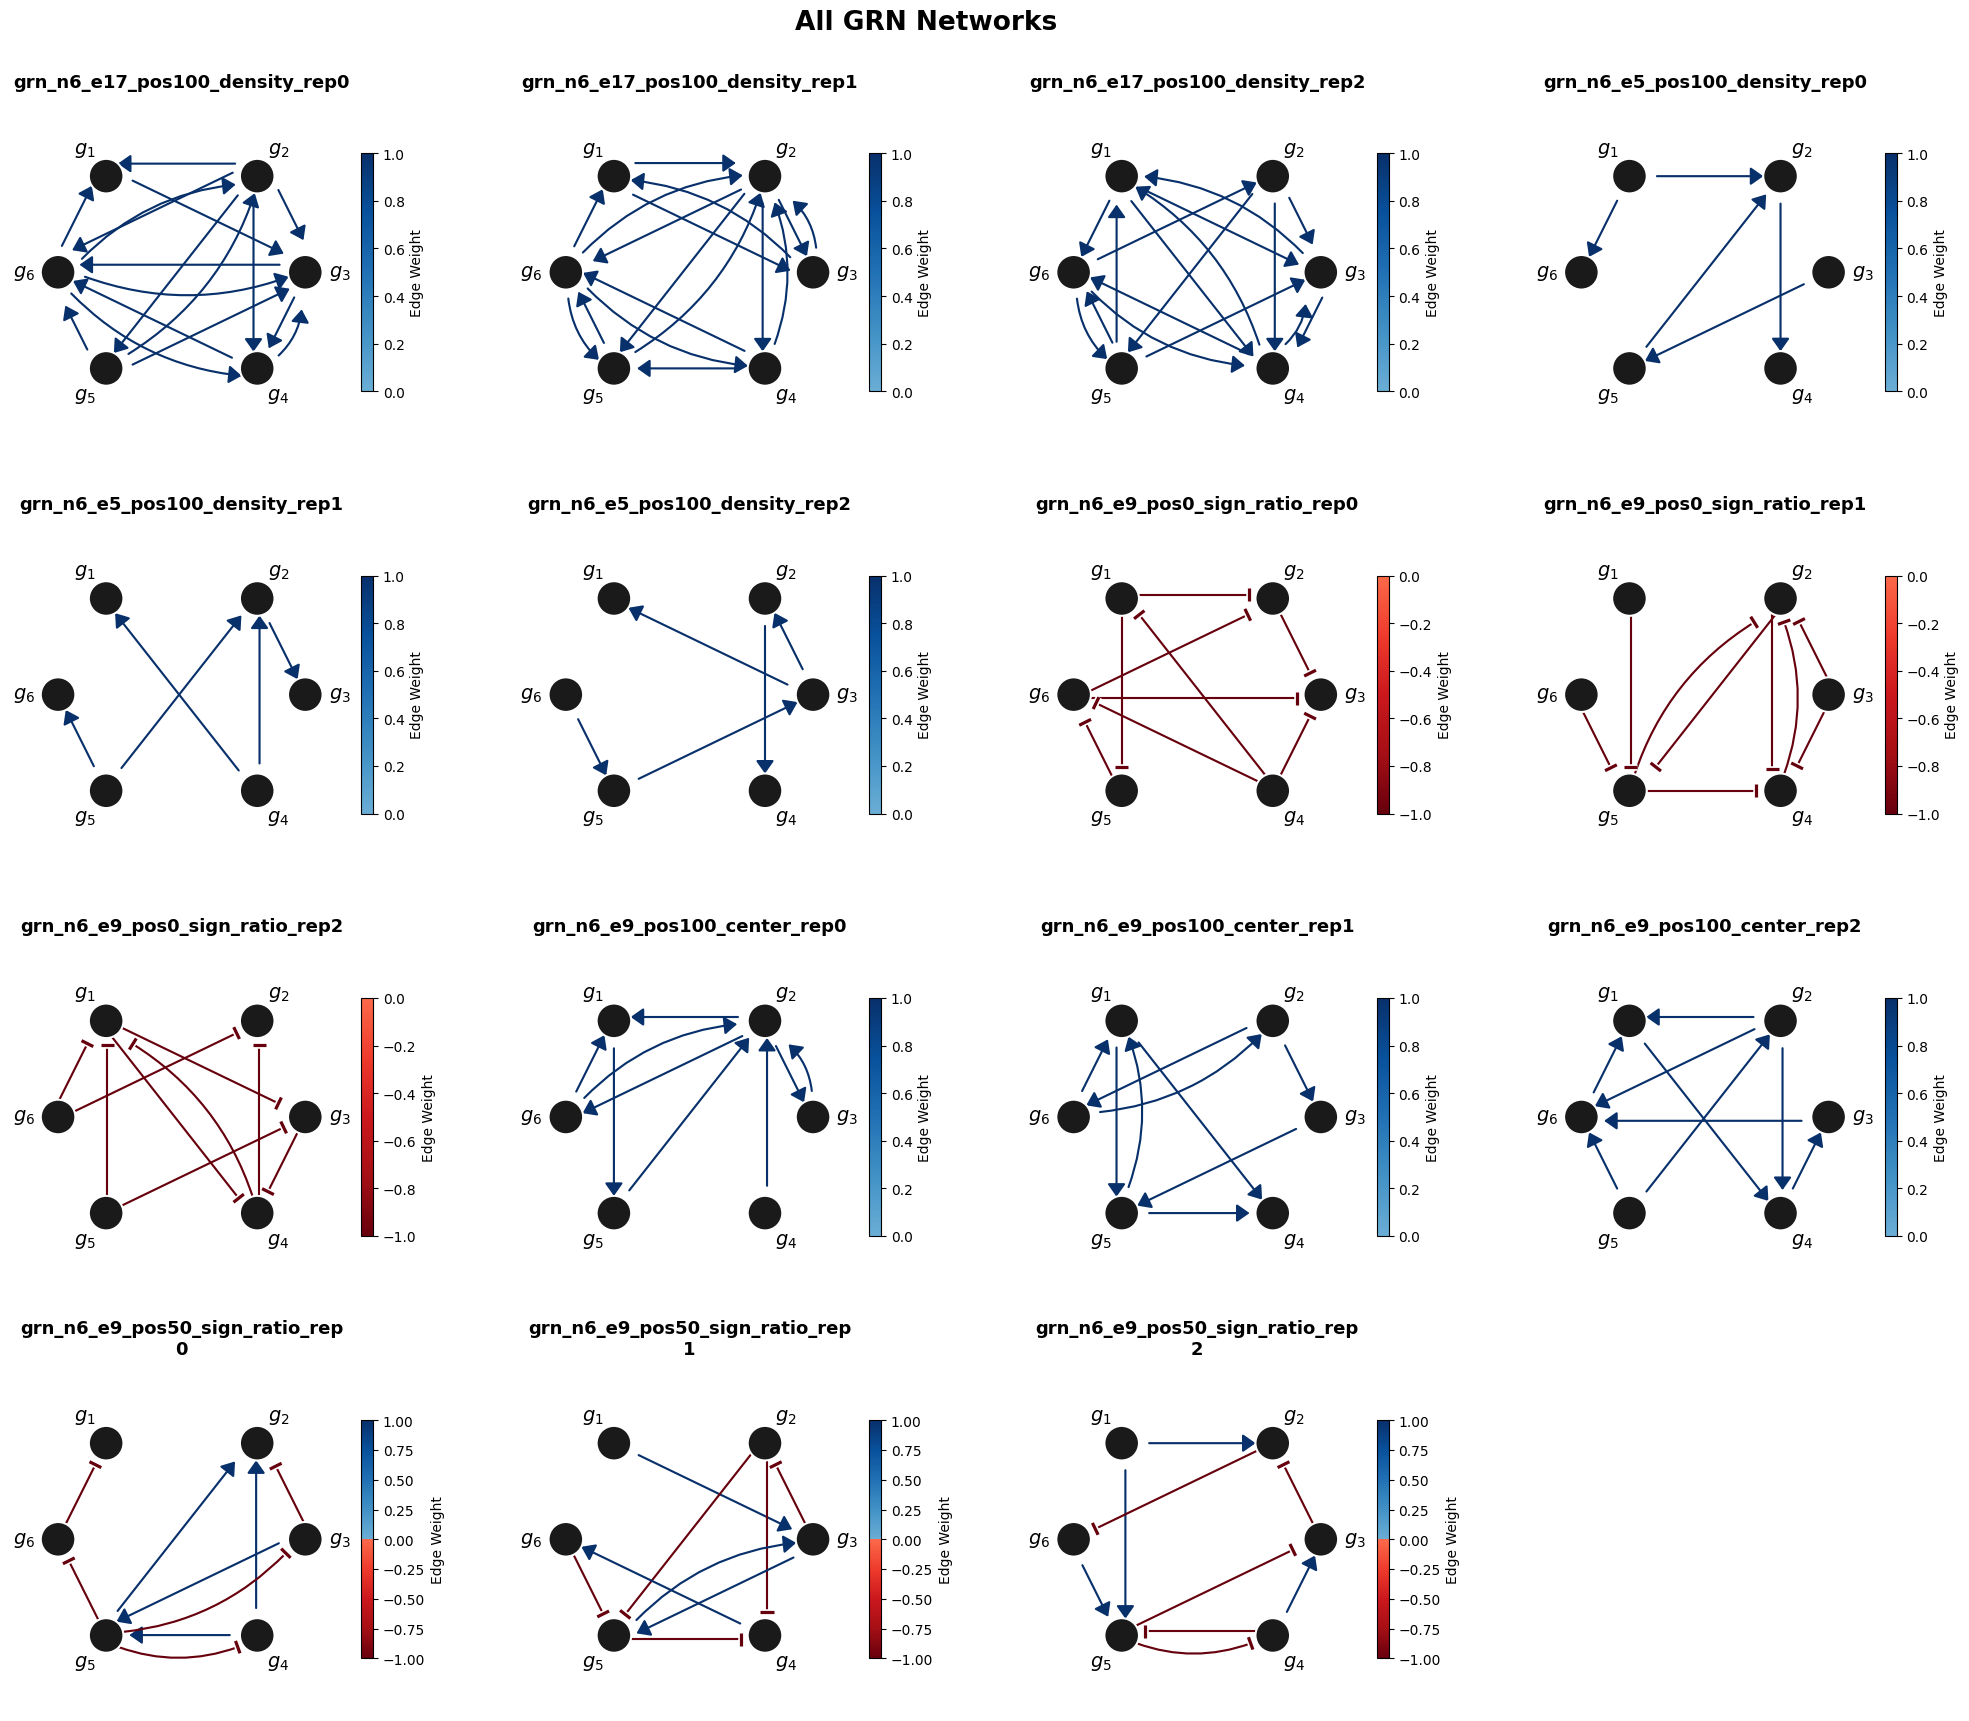

In [11]:
import os
import sys
import glob
import math
import textwrap
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. Paths
# ============================================================

module_dir = "/home/gzu5140/Keerthana_b1042/TwINFER"

path_to_networks = os.path.join(
    module_dir,
    "input_data",
    "network_sweep_final",
)

output_dir = os.path.join(
    module_dir,
    "network_figures",
)

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# 1. Reload plotting module
# ============================================================

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

importlib.invalidate_caches()

import grn_plot_spread_v2
importlib.reload(grn_plot_spread_v2)

from grn_plot_spread_v2 import plot_grn as plot_grn_spread

print("Loaded plotting module from:")
print(grn_plot_spread_v2.__file__)
print("plot_grn signature:")
print(inspect.signature(plot_grn_spread))
print("Plot module version:", grn_plot_spread_v2.__version__)

if "terminal_spread" not in inspect.signature(plot_grn_spread).parameters:
    raise RuntimeError(
        "The loaded grn_plot_spread_v3_g1_fixed.py is an old version without "
        "terminal_spread. Replace the file shown above and rerun."
    )


# ============================================================
# 2. Find all matrix files
# ============================================================

files = sorted(
    glob.glob(
        os.path.join(path_to_networks, "*.txt")
    )
)

if not files:
    raise FileNotFoundError(
        f"No .txt files found in:\n{path_to_networks}"
    )

print(f"Found {len(files)} network files")


# ============================================================
# 3. Matrix loader
# ============================================================

def load_network_matrix(file_path):
    """
    Load a comma-separated or whitespace-separated square matrix.
    """

    try:
        matrix = np.loadtxt(
            file_path,
            delimiter=",",
        )
    except ValueError:
        matrix = np.loadtxt(file_path)

    matrix = np.asarray(
        matrix,
        dtype=float,
    )

    if matrix.ndim != 2:
        raise ValueError(
            f"Matrix is not 2D: shape={matrix.shape}"
        )

    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError(
            f"Matrix is not square: shape={matrix.shape}"
        )

    if not np.all(np.isfinite(matrix)):
        raise ValueError(
            "Matrix contains NaN or infinite values."
        )

    matrix = matrix.copy()

    # Remove diagonal self-loops.
    np.fill_diagonal(matrix, 0.0)

    return matrix


# ============================================================
# 4. Load all valid matrices
# ============================================================

network_data = []

for file_index, file_path in enumerate(
    files,
    start=1,
):
    network_name = os.path.splitext(
        os.path.basename(file_path)
    )[0]

    try:
        matrix = load_network_matrix(file_path)

    except Exception as error:
        print(
            f"[{file_index}/{len(files)}] "
            f"Skipped {network_name}: {error}"
        )
        continue

    network_data.append(
        {
            "name": network_name,
            "path": file_path,
            "matrix": matrix,
        }
    )

    print(
        f"[{file_index}/{len(files)}] "
        f"Loaded {network_name}: "
        f"shape={matrix.shape}, "
        f"edges={np.count_nonzero(matrix)}"
    )

if not network_data:
    raise RuntimeError(
        "No valid matrices were loaded."
    )


# ============================================================
# 5. Confirm that all matrices have the same node count
# ============================================================

node_counts = {
    item["matrix"].shape[0]
    for item in network_data
}

if len(node_counts) != 1:
    raise ValueError(
        "The matrices do not all have the same number of nodes. "
        f"Found node counts: {sorted(node_counts)}"
    )

n_nodes = next(iter(node_counts))
n_networks = len(network_data)

print("\nNumber of valid networks:", n_networks)
print("Nodes per network:", n_nodes)


# ============================================================
# 6. Fixed node layout
# ============================================================

if n_nodes == 6:
    # Clockwise node order, keeping g1 in its original upper-left position:
    #
    #             g1        g2
    #
    #        g6                  g3
    #
    #             g5        g4
    #
    fixed_pos = {
        0: np.array([0.28, 0.78]),  # g1: upper-left, unchanged
        1: np.array([0.72, 0.78]),  # g2: upper-right
        2: np.array([0.86, 0.50]),  # g3: right
        3: np.array([0.72, 0.22]),  # g4: lower-right
        4: np.array([0.28, 0.22]),  # g5: lower-left
        5: np.array([0.14, 0.50]),  # g6: left
    }

else:
    # Generic circular layout for a different number of nodes.
    angles = np.linspace(
        np.pi / 2,
        np.pi / 2 - 2 * np.pi,
        n_nodes,
        endpoint=False,
    )

    fixed_pos = {
        node: np.array(
            [
                0.5 + 0.36 * np.cos(angle),
                0.5 + 0.36 * np.sin(angle),
            ]
        )
        for node, angle in enumerate(angles)
    }


# ============================================================
# 7. Subplot grid
# ============================================================

if n_networks <= 3:
    n_cols = n_networks
elif n_networks <= 9:
    n_cols = 3
elif n_networks <= 16:
    n_cols = 4
else:
    n_cols = 5

n_rows = math.ceil(
    n_networks / n_cols
)

panel_width = 5.0
panel_height = 4.4

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(
        panel_width * n_cols,
        panel_height * n_rows,
    ),
    squeeze=False,
)

axes_flat = axes.ravel()


# ============================================================
# 8. Plot every network
# ============================================================

for index, network in enumerate(network_data):
    ax = axes_flat[index]

    matrix = network["matrix"]
    network_name = network["name"]

    labels = [
        f"$g_{{{node + 1}}}$"
        for node in range(n_nodes)
    ]

    wrapped_title = "\n".join(
        textwrap.wrap(
            network_name,
            width=30,
            break_long_words=True,
            break_on_hyphens=True,
        )
    )

    print(
        f"Plotting [{index + 1}/{n_networks}]: "
        f"{network_name}"
    )

    try:
        plot_grn_spread(
            matrix,
            node_labels=labels,
            title=wrapped_title,
            ax=ax,
            fixed_pos=fixed_pos,
            show_colorbar=True,
            font_size=11,
            terminal_spread=0.9,
            terminal_angle_tolerance=1.10,
            reciprocal_separation=0.70,
            max_shift_fraction=0.95,

    )

        # Keep every panel in exactly the same coordinate range.
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.axis("off")

    except Exception as error:
        ax.clear()
        ax.axis("off")

        ax.text(
            0.5,
            0.5,
            (
                f"Plot failed\n"
                f"{network_name}\n\n"
                f"{type(error).__name__}: {error}"
            ),
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )

        print(
            f"Plot failed for {network_name}: {error}"
        )


# ============================================================
# 9. Hide unused panels
# ============================================================

for index in range(
    n_networks,
    len(axes_flat),
):
    axes_flat[index].axis("off")


# ============================================================
# 10. Final formatting
# ============================================================

fig.suptitle(
    "All GRN Networks",
    fontsize=19,
    fontweight="bold",
    y=0.992,
)

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    bottom=0.025,
    top=0.94,
    wspace=0.28,
    hspace=0.23,
)


# ============================================================
# 11. Save
# ============================================================

output_png = os.path.join(
    output_dir,
    "all_networks_fixed_layout.png",
)

output_pdf = os.path.join(
    output_dir,
    "all_networks_fixed_layout.pdf",
)

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved PNG:")
print(output_png)

print("\nSaved PDF:")
print(output_pdf)


# ============================================================
# 12. Display
# ============================================================

plt.show()
plt.close(fig)

Loaded plotting module from:
/projects/b1042/GoyalLab/Keerthana/TwINFER/code/TwINFER/synthetic_network_analysis/grn_plot_spread_v2.py
plot_grn signature:
(matrix, node_labels=None, figsize=None, node_color='#1a1a1a', font_size=None, label_font_size=None, font_color='black', title=None, ax=None, fixed_pos=None, show_colorbar=True, vmin=None, vmax=None, *, terminal_spread=0.38, terminal_angle_tolerance=1.1, reciprocal_separation=0.3, reciprocal_curve=0.18, terminal_depth_step=0.35, max_shift_fraction=0.92, edge_halo=True)
Plot module version: 2026-07-16-one-reciprocal-edge-curved-v6
Found 15 network files
[1/15] Loaded grn_n6_e17_pos50_density_rep0: shape=(6, 6), edges=17
[2/15] Loaded grn_n6_e17_pos50_density_rep1: shape=(6, 6), edges=17
[3/15] Loaded grn_n6_e17_pos50_density_rep2: shape=(6, 6), edges=17
[4/15] Loaded grn_n6_e5_pos50_density_rep0: shape=(6, 6), edges=5
[5/15] Loaded grn_n6_e5_pos50_density_rep1: shape=(6, 6), edges=5
[6/15] Loaded grn_n6_e5_pos50_density_rep2: shape=(6,

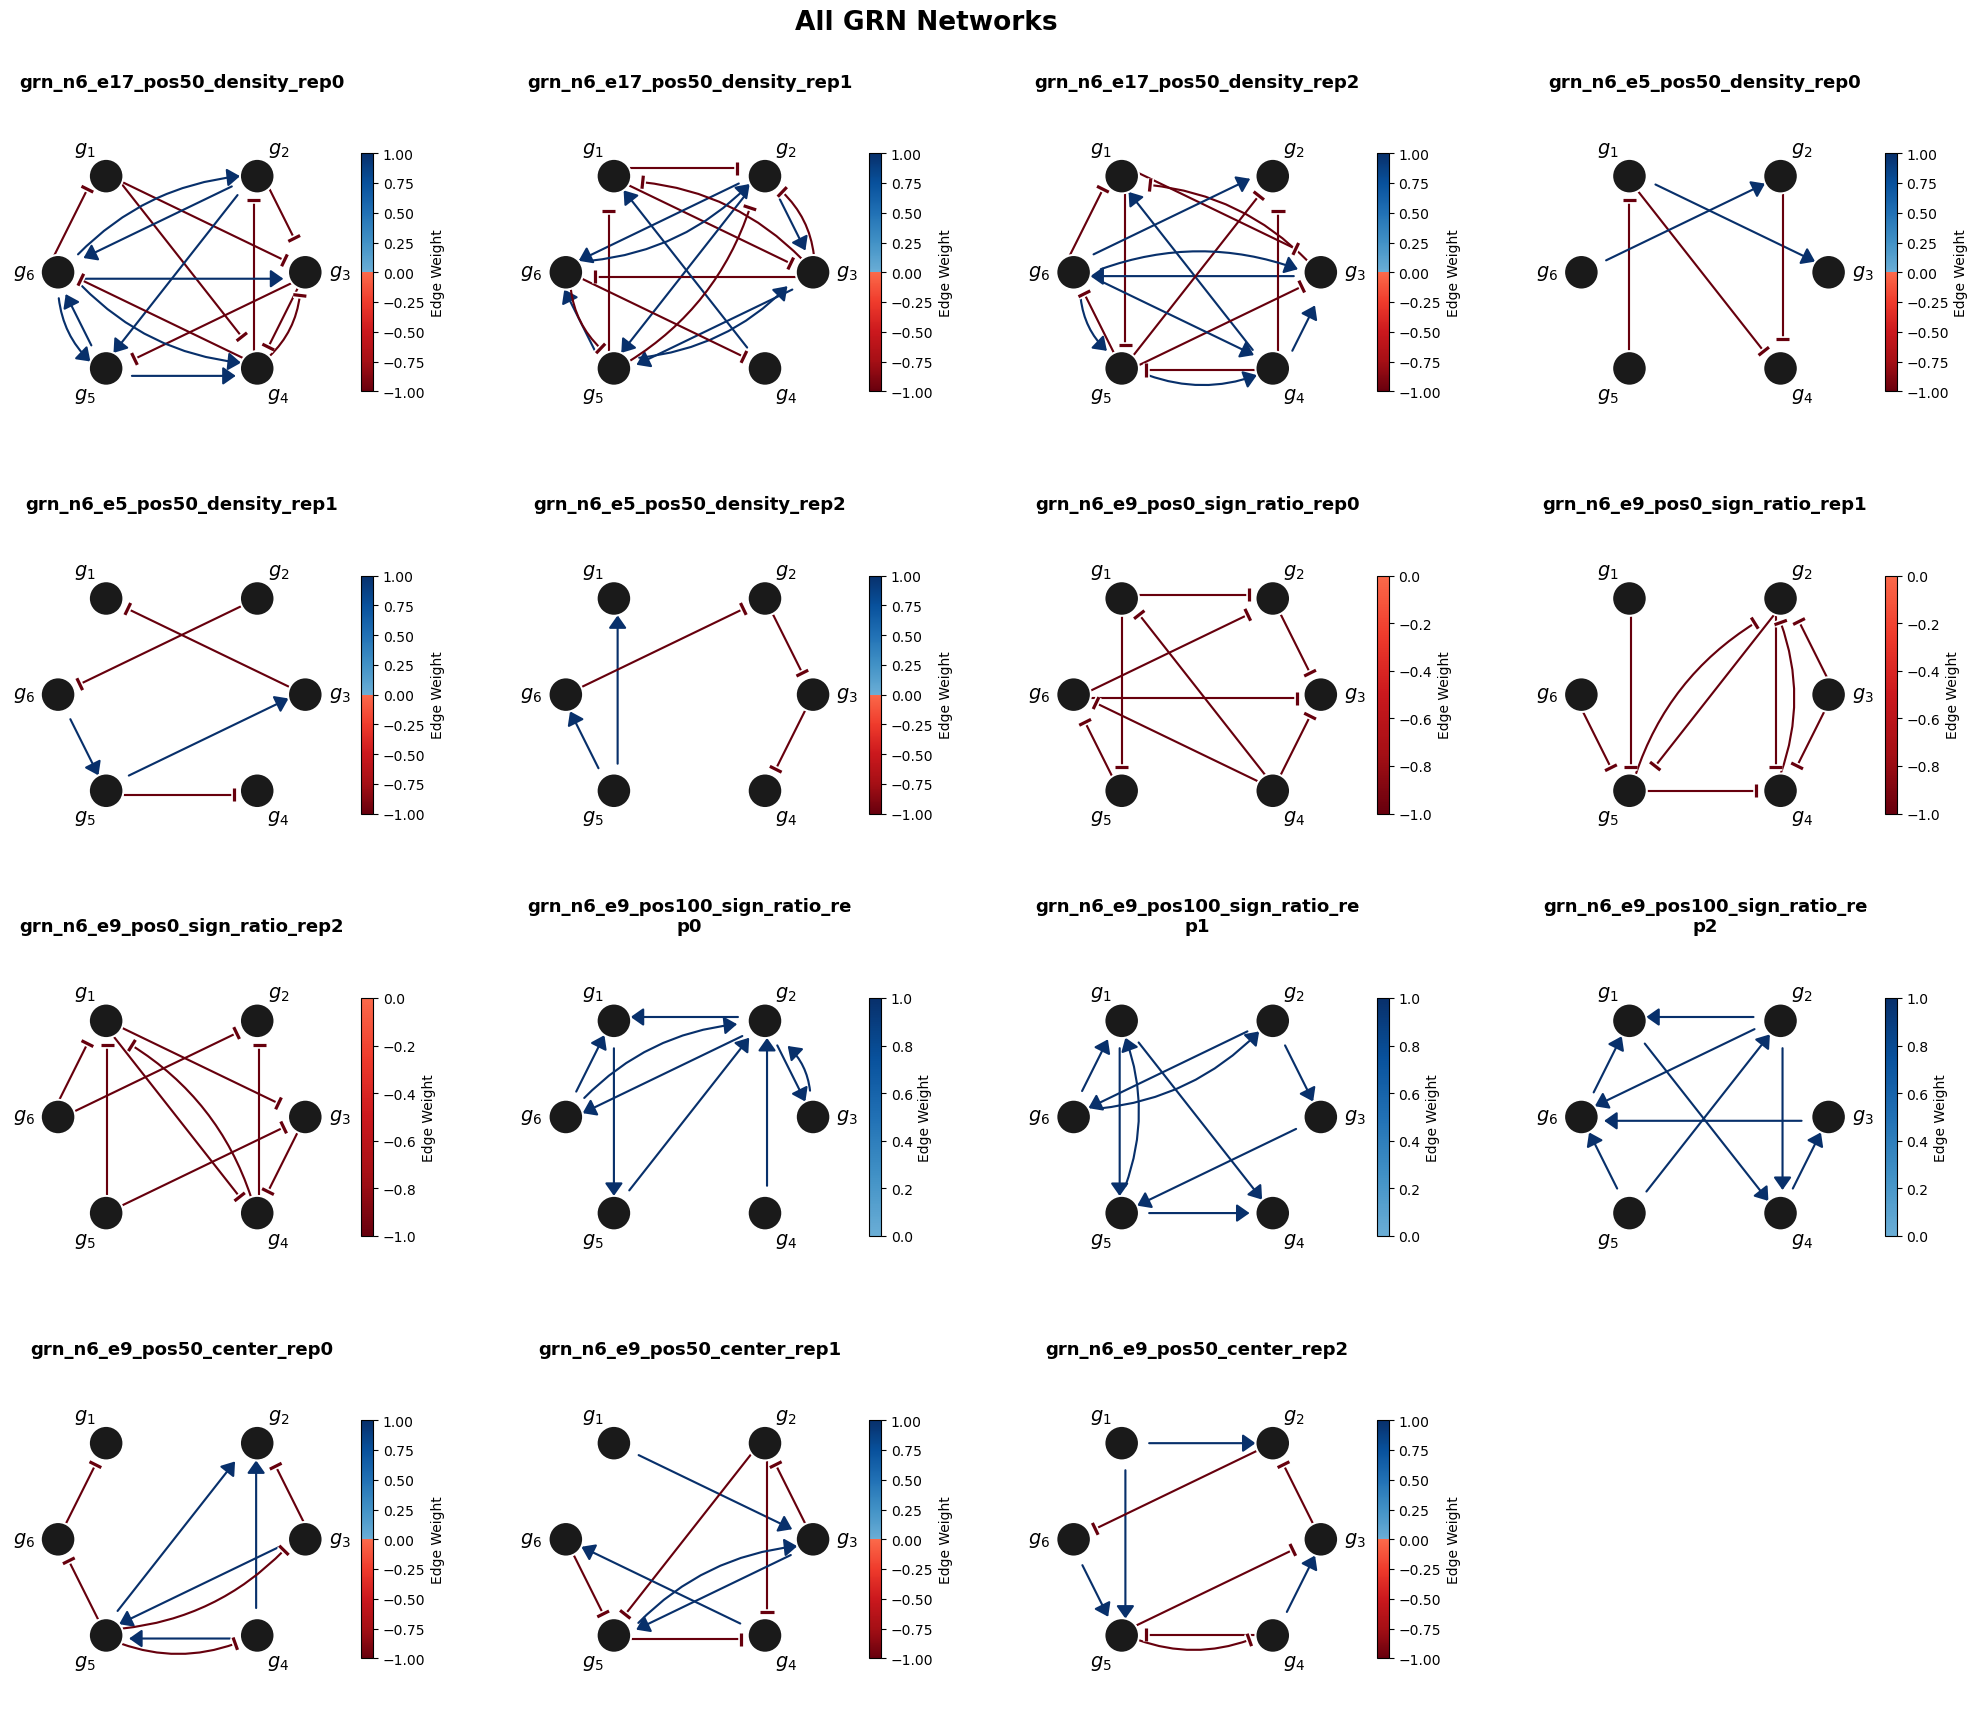

In [50]:
import os
import sys
import glob
import math
import textwrap
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. Paths
# ============================================================

module_dir = "/home/gzu5140/Keerthana_b1042/TwINFER"

path_to_networks = os.path.join(
    module_dir,
    "input_data",
    "network_sweep",
)

output_dir = os.path.join(
    module_dir,
    "network_figures",
)

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# 1. Reload plotting module
# ============================================================

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

importlib.invalidate_caches()

import grn_plot_spread_v2
importlib.reload(grn_plot_spread_v2)

from grn_plot_spread_v2 import plot_grn as plot_grn_spread

print("Loaded plotting module from:")
print(grn_plot_spread_v2.__file__)
print("plot_grn signature:")
print(inspect.signature(plot_grn_spread))
print("Plot module version:", grn_plot_spread_v2.__version__)

if "terminal_spread" not in inspect.signature(plot_grn_spread).parameters:
    raise RuntimeError(
        "The loaded grn_plot_spread_v3_g1_fixed.py is an old version without "
        "terminal_spread. Replace the file shown above and rerun."
    )


# ============================================================
# 2. Find all matrix files
# ============================================================

files = sorted(
    glob.glob(
        os.path.join(path_to_networks, "*.txt")
    )
)

if not files:
    raise FileNotFoundError(
        f"No .txt files found in:\n{path_to_networks}"
    )

print(f"Found {len(files)} network files")


# ============================================================
# 3. Matrix loader
# ============================================================

def load_network_matrix(file_path):
    """
    Load a comma-separated or whitespace-separated square matrix.
    """

    try:
        matrix = np.loadtxt(
            file_path,
            delimiter=",",
        )
    except ValueError:
        matrix = np.loadtxt(file_path)

    matrix = np.asarray(
        matrix,
        dtype=float,
    )

    if matrix.ndim != 2:
        raise ValueError(
            f"Matrix is not 2D: shape={matrix.shape}"
        )

    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError(
            f"Matrix is not square: shape={matrix.shape}"
        )

    if not np.all(np.isfinite(matrix)):
        raise ValueError(
            "Matrix contains NaN or infinite values."
        )

    matrix = matrix.copy()

    # Remove diagonal self-loops.
    np.fill_diagonal(matrix, 0.0)

    return matrix


# ============================================================
# 4. Load all valid matrices
# ============================================================

network_data = []

for file_index, file_path in enumerate(
    files,
    start=1,
):
    network_name = os.path.splitext(
        os.path.basename(file_path)
    )[0]

    try:
        matrix = load_network_matrix(file_path)

    except Exception as error:
        print(
            f"[{file_index}/{len(files)}] "
            f"Skipped {network_name}: {error}"
        )
        continue

    network_data.append(
        {
            "name": network_name,
            "path": file_path,
            "matrix": matrix,
        }
    )

    print(
        f"[{file_index}/{len(files)}] "
        f"Loaded {network_name}: "
        f"shape={matrix.shape}, "
        f"edges={np.count_nonzero(matrix)}"
    )

if not network_data:
    raise RuntimeError(
        "No valid matrices were loaded."
    )


# ============================================================
# 5. Confirm that all matrices have the same node count
# ============================================================

node_counts = {
    item["matrix"].shape[0]
    for item in network_data
}

if len(node_counts) != 1:
    raise ValueError(
        "The matrices do not all have the same number of nodes. "
        f"Found node counts: {sorted(node_counts)}"
    )

n_nodes = next(iter(node_counts))
n_networks = len(network_data)

print("\nNumber of valid networks:", n_networks)
print("Nodes per network:", n_nodes)


# ============================================================
# 6. Fixed node layout
# ============================================================

if n_nodes == 6:
    # Clockwise node order, keeping g1 in its original upper-left position:
    #
    #             g1        g2
    #
    #        g6                  g3
    #
    #             g5        g4
    #
    fixed_pos = {
        0: np.array([0.28, 0.78]),  # g1: upper-left, unchanged
        1: np.array([0.72, 0.78]),  # g2: upper-right
        2: np.array([0.86, 0.50]),  # g3: right
        3: np.array([0.72, 0.22]),  # g4: lower-right
        4: np.array([0.28, 0.22]),  # g5: lower-left
        5: np.array([0.14, 0.50]),  # g6: left
    }

else:
    # Generic circular layout for a different number of nodes.
    angles = np.linspace(
        np.pi / 2,
        np.pi / 2 - 2 * np.pi,
        n_nodes,
        endpoint=False,
    )

    fixed_pos = {
        node: np.array(
            [
                0.5 + 0.36 * np.cos(angle),
                0.5 + 0.36 * np.sin(angle),
            ]
        )
        for node, angle in enumerate(angles)
    }


# ============================================================
# 7. Subplot grid
# ============================================================

if n_networks <= 3:
    n_cols = n_networks
elif n_networks <= 9:
    n_cols = 3
elif n_networks <= 16:
    n_cols = 4
else:
    n_cols = 5

n_rows = math.ceil(
    n_networks / n_cols
)

panel_width = 5.0
panel_height = 4.4

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(
        panel_width * n_cols,
        panel_height * n_rows,
    ),
    squeeze=False,
)

axes_flat = axes.ravel()


# ============================================================
# 8. Plot every network
# ============================================================

for index, network in enumerate(network_data):
    ax = axes_flat[index]

    matrix = network["matrix"]
    network_name = network["name"]

    labels = [
        f"$g_{{{node + 1}}}$"
        for node in range(n_nodes)
    ]

    wrapped_title = "\n".join(
        textwrap.wrap(
            network_name,
            width=30,
            break_long_words=True,
            break_on_hyphens=True,
        )
    )

    print(
        f"Plotting [{index + 1}/{n_networks}]: "
        f"{network_name}"
    )

    try:
        plot_grn_spread(
        matrix,
        node_labels=labels,
        title=wrapped_title,
        ax=ax,
        fixed_pos=fixed_pos,
        show_colorbar=True,
        font_size=11,

        terminal_spread=0.9,
        terminal_angle_tolerance=1.10,

        reciprocal_separation=0.30,
        reciprocal_curve=0.18,

        terminal_depth_step=0.35,
        max_shift_fraction=0.92,
)


        # Keep every panel in exactly the same coordinate range.
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.axis("off")

    except Exception as error:
        ax.clear()
        ax.axis("off")

        ax.text(
            0.5,
            0.5,
            (
                f"Plot failed\n"
                f"{network_name}\n\n"
                f"{type(error).__name__}: {error}"
            ),
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )

        print(
            f"Plot failed for {network_name}: {error}"
        )


# ============================================================
# 9. Hide unused panels
# ============================================================

for index in range(
    n_networks,
    len(axes_flat),
):
    axes_flat[index].axis("off")


# ============================================================
# 10. Final formatting
# ============================================================

fig.suptitle(
    "All GRN Networks",
    fontsize=19,
    fontweight="bold",
    y=0.992,
)

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    bottom=0.025,
    top=0.94,
    wspace=0.28,
    hspace=0.23,
)


# ============================================================
# 11. Save
# ============================================================

output_png = os.path.join(
    output_dir,
    "all_networks_fixed_layout.png",
)

output_pdf = os.path.join(
    output_dir,
    "all_networks_fixed_layout.pdf",
)

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved PNG:")
print(output_png)

print("\nSaved PDF:")
print(output_pdf)


# ============================================================
# 12. Display
# ============================================================

plt.show()
plt.close(fig)

## Real-world networks: ground truth (HSC, GSD, mCAD, VSC)

Draws the ground-truth network for each real-world benchmark network in `input_data/real_world_networks/` (ground truth only, no inferred edges).

Gene names are used as node labels where available (HSC, mCAD, VSC), taken from `network_labels.txt`. GSD has no gene-name key there, so it falls back to the generic `g1..g19` labeling used elsewhere in this notebook.

Loaded plotting module from:
/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER/synthetic_network_analysis/grn_plot_spread_v2.py
plot_grn signature:
(matrix, node_labels=None, figsize=None, node_color='#1a1a1a', font_size=None, label_font_size=None, font_color='black', title=None, ax=None, fixed_pos=None, show_colorbar=True, vmin=None, vmax=None, *, terminal_spread=0.38, terminal_angle_tolerance=1.1, reciprocal_separation=0.3, reciprocal_curve=0.18, terminal_depth_step=0.35, max_shift_fraction=0.92, edge_halo=True)
Plot module version: 2026-07-16-one-reciprocal-edge-curved-v6

Real-world ground-truth networks loaded: 4
  HSC: 11 genes
  GSD: 19 genes
  mCAD: 5 genes
  VSC: 8 genes
Plotting [1/4]: HSC
Plotting [2/4]: GSD
Plotting [3/4]: mCAD
Plotting [4/4]: VSC

Saved PNG:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/real_world_networks_ground_truth.png

Saved PDF:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/real_world_networks_ground_truth.pdf


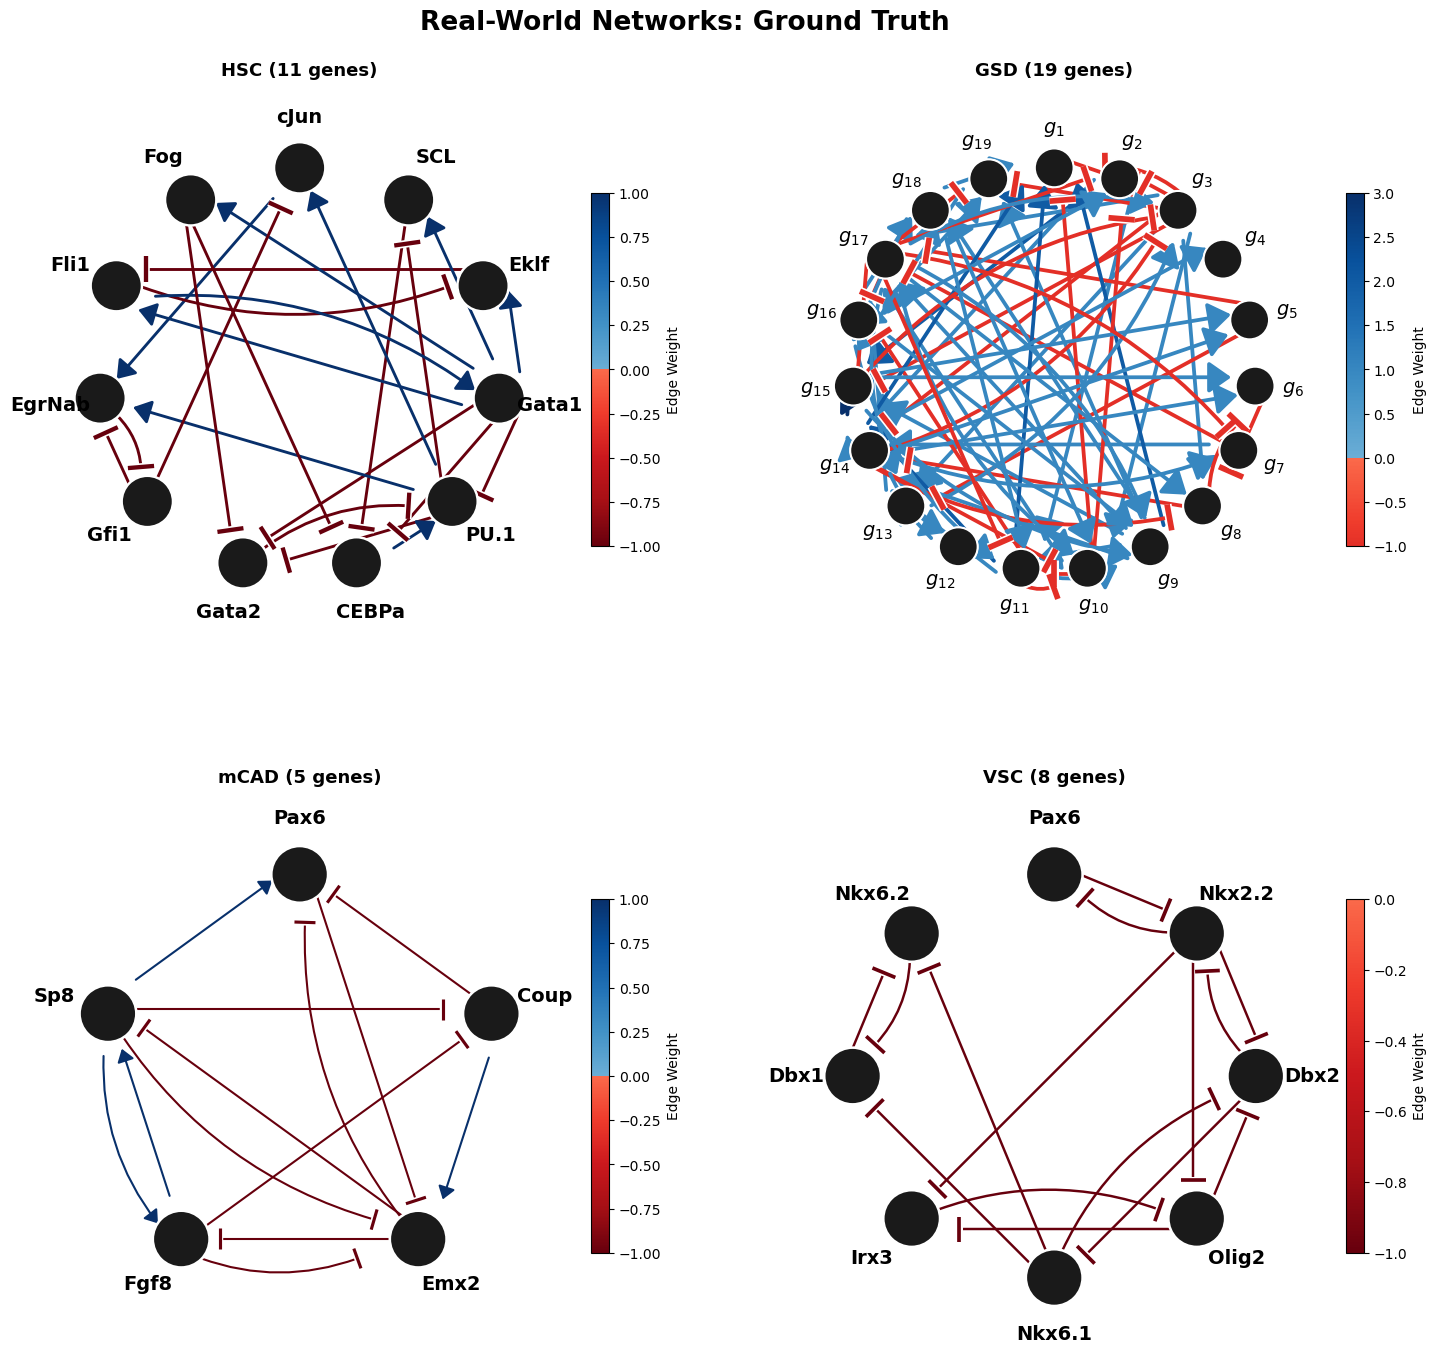

In [10]:
import os
import sys
import glob
import math
import textwrap
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 0. Paths
# ============================================================================

module_dir = "/home/gzu5140/Keerthana_b1042/TwINFER"

path_to_networks = os.path.join(
    module_dir,
    "input_data",
    "real_world_networks",
)

output_dir = os.path.join(
    module_dir,
    "network_figures",
)

os.makedirs(output_dir, exist_ok=True)

# ============================================================================
# 1. Reload plotting module
# ============================================================================

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

sys.path.insert(0, os.path.join(module_dir, "code", "TwINFER", "synthetic_network_analysis"))

importlib.invalidate_caches()

import grn_plot_spread_v2
importlib.reload(grn_plot_spread_v2)

from grn_plot_spread_v2 import plot_grn as plot_grn_spread

print("Loaded plotting module from:")
print(grn_plot_spread_v2.__file__)
print("plot_grn signature:")
print(inspect.signature(plot_grn_spread))
print("Plot module version:", grn_plot_spread_v2.__version__)

if "terminal_spread" not in inspect.signature(plot_grn_spread).parameters:
    raise RuntimeError(
        "The loaded grn_plot_spread_v2.py is an old version without "
        "terminal_spread. Replace the file shown above and rerun."
    )

# ============================================================================
# 2. Real-world networks to plot (ground truth only)
# ============================================================================

# Order matches the requested order: hsc, gsd, mcad, vsc.
real_world_files = [
    "HSC.txt",
    "GSD.txt",
    "mCAD.txt",
    "VSC.txt",
]

# Gene names taken from network_labels.txt. GSD has no gene-name key there,
# so it falls back to the generic g1..gN convention used elsewhere in this
# notebook.
gene_name_labels = {
    "mCAD": ["Pax6", "Coup", "Emx2", "Fgf8", "Sp8"],
    "VSC": ["Pax6", "Nkx2.2", "Dbx2", "Olig2", "Nkx6.1", "Irx3", "Dbx1", "Nkx6.2"],
    "HSC": ["cJun", "SCL", "Eklf", "Gata1", "PU.1", "CEBPa", "Gata2", "Gfi1", "EgrNab", "Fli1", "Fog"],
}

# ============================================================================
# 3. Matrix loader
# ============================================================================

def load_network_matrix(file_path):
    """
    Load a comma-separated or whitespace-separated square matrix.
    """

    try:
        matrix = np.loadtxt(
            file_path,
            delimiter=",",
        )
    except ValueError:
        matrix = np.loadtxt(file_path)

    matrix = np.asarray(
        matrix,
        dtype=float,
    )

    return matrix

# ============================================================================
# 4. Load all real-world ground-truth matrices
# ============================================================================

network_data = []

for file_name in real_world_files:
    network_name = os.path.splitext(file_name)[0]
    file_path = os.path.join(path_to_networks, file_name)

    try:
        matrix = load_network_matrix(file_path)
    except Exception as error:
        print(f"Skipped {network_name}: {error}")
        continue

    network_data.append(
        {
            "matrix": matrix,
            "name": network_name,
        }
    )

if not network_data:
    raise RuntimeError("No valid matrices were loaded.")

n_networks = len(network_data)

print("\nReal-world ground-truth networks loaded:", n_networks)
for item in network_data:
    n = item["matrix"].shape[0]
    print(f"  {item['name']}: {n} genes")

# ============================================================================
# 5. Subplot grid
# ============================================================================

# Exactly 4 (larger, denser) networks -- a clean 2x2 grid reads better than
# leaving empty panels.
n_cols = 2
n_rows = -(-n_networks // n_cols)
panel_size = 7

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(panel_size * n_cols, panel_size * n_rows),
    squeeze=False,
)
axes_flat = axes.flatten()

# ============================================================================
# 6. Plot every network
# ============================================================================

for index, network in enumerate(network_data):
    ax = axes_flat[index]

    matrix = network["matrix"]
    network_name = network["name"]
    n_genes = matrix.shape[0]

    if network_name in gene_name_labels:
        labels = gene_name_labels[network_name]
    else:
        labels = [f"$g_{{{gene + 1}}}$" for gene in range(n_genes)]

    # Generic circular layout -- these networks vary in size, so there is
    # no single fixed hex layout that fits all of them (matches the
    # fallback layout used elsewhere in this notebook for n_nodes != 6).
    angles = np.linspace(
        np.pi / 2,
        np.pi / 2 - 2 * np.pi,
        n_genes,
        endpoint=False,
    )

    fixed_pos = {
        gene: np.array(
            [
                0.5 + 0.36 * np.cos(angle),
                0.5 + 0.36 * np.sin(angle),
            ]
        )
        for gene, angle in enumerate(angles)
    }

    wrapped_title = "\n".join(
        textwrap.wrap(
            f"{network_name} ({n_genes} genes)",
            width=30,
            break_long_words=True,
            break_on_hyphens=True,
        )
    )

    print(f"Plotting [{index + 1}/{n_networks}]: {network_name}")

    try:
        plot_grn_spread(
            matrix,
            node_labels=labels,
            title=wrapped_title,
            ax=ax,
            fixed_pos=fixed_pos,
            show_colorbar=True,
            font_size=11,
            terminal_spread=0.9,
            terminal_angle_tolerance=1.10,
            reciprocal_separation=0.70,
            max_shift_fraction=0.95,
        )

        # Keep every panel in exactly the same coordinate range.
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.axis("off")

    except Exception as error:
        ax.clear()
        ax.axis("off")

        ax.text(
            0.5,
            0.5,
            (
                f"Plot failed\n"
                f"{network_name}\n\n"
                f"{type(error).__name__}: {error}"
            ),
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )

        print(f"Plot failed for {network_name}: {error}")

# ============================================================================
# 7. Hide unused panels
# ============================================================================

for index in range(n_networks, len(axes_flat)):
    axes_flat[index].axis("off")

# ============================================================================
# 8. Final formatting
# ============================================================================

fig.suptitle(
    "Real-World Networks: Ground Truth",
    fontsize=19,
    fontweight="bold",
    y=0.992,
)

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    bottom=0.025,
    top=0.94,
    wspace=0.28,
    hspace=0.23,
)

# ============================================================================
# 9. Save
# ============================================================================

output_png = os.path.join(
    output_dir,
    "real_world_networks_ground_truth.png",
)

output_pdf = os.path.join(
    output_dir,
    "real_world_networks_ground_truth.pdf",
)

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved PNG:")
print(output_png)

print("\nSaved PDF:")
print(output_pdf)

# ============================================================================
# 10. Display
# ============================================================================

plt.show()
plt.close(fig)


Loaded plotting module from:
/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER/synthetic_network_analysis/grn_plot_spread_v2.py
plot_grn signature:
(matrix, node_labels=None, figsize=None, node_color='#1a1a1a', font_size=None, label_font_size=None, font_color='black', title=None, ax=None, fixed_pos=None, show_colorbar=True, vmin=None, vmax=None, *, terminal_spread=0.38, terminal_angle_tolerance=1.1, reciprocal_separation=0.3, reciprocal_curve=0.18, terminal_depth_step=0.35, max_shift_fraction=0.92, edge_halo=True, bow_non_reciprocal_edges=True, non_reciprocal_curve=0.18)
Plot module version: 2026-07-16-one-reciprocal-edge-curved-v6

Main real-world ground-truth networks loaded:
  HSC: 11 genes
  mCAD: 5 genes
  VSC: 8 genes
Plotting main network [1/3]: HSC
Plotting main network [2/3]: mCAD
Plotting main network [3/3]: VSC

Saved main-networks PNG:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/real_world_networks_ground_truth_main_only.png

Saved main-networks PDF:
/home/gzu514

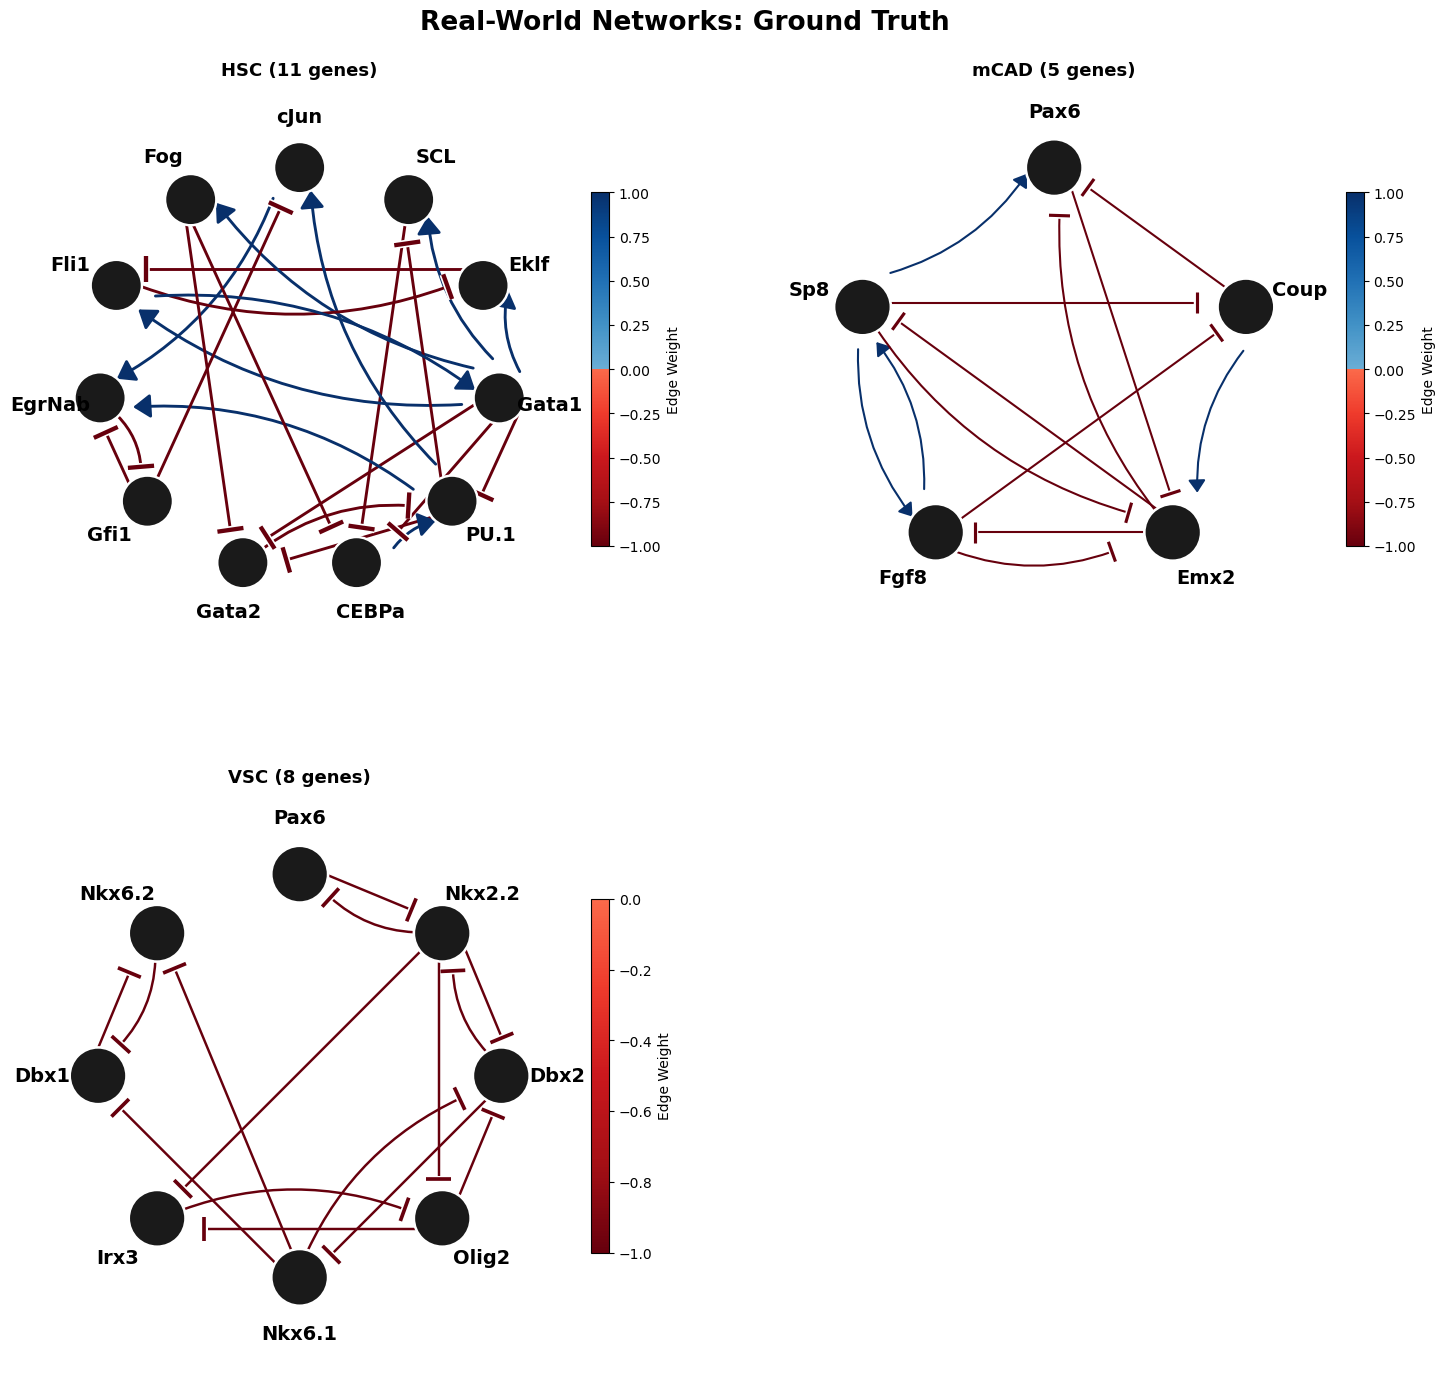


Plotting GSD separately...
GSD: 19 genes

Saved GSD PNG:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/GSD_ground_truth.png

Saved GSD PDF:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/GSD_ground_truth.pdf


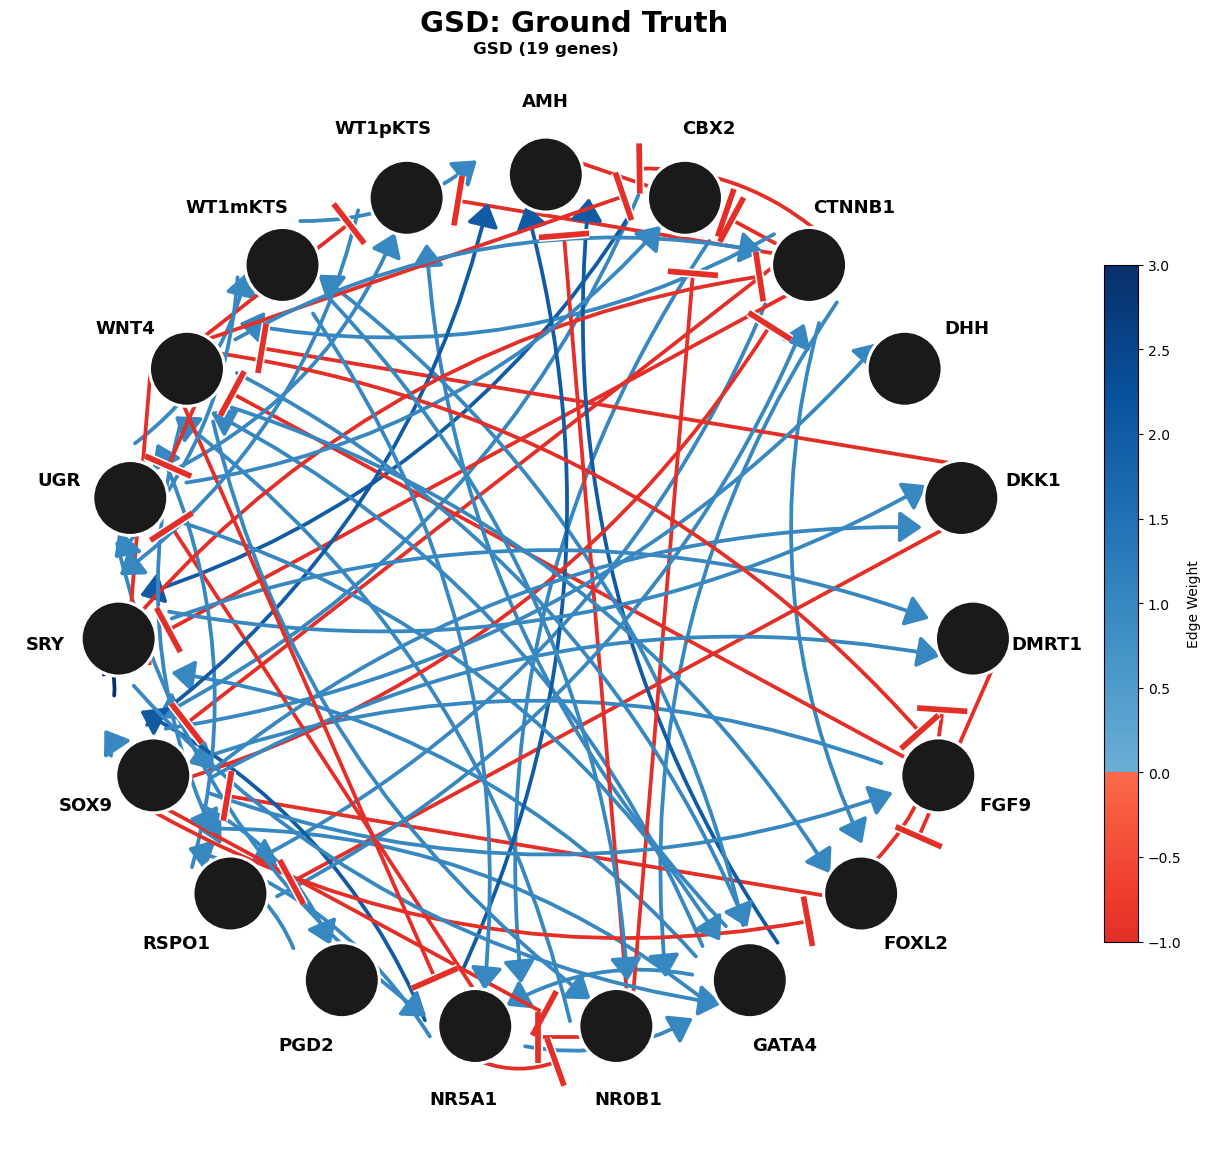

In [13]:
import os
import sys
import textwrap
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 0. Paths
# ============================================================================

module_dir = "/home/gzu5140/Keerthana_b1042/TwINFER"

path_to_networks = os.path.join(
    module_dir,
    "input_data",
    "real_world_networks",
)

output_dir = os.path.join(
    module_dir,
    "network_figures",
)

os.makedirs(output_dir, exist_ok=True)

# ============================================================================
# 1. Reload plotting module
# ============================================================================

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

sys.path.insert(
    0,
    os.path.join(module_dir, "code", "TwINFER", "synthetic_network_analysis"),
)

importlib.invalidate_caches()

import grn_plot_spread_v2
importlib.reload(grn_plot_spread_v2)

from grn_plot_spread_v2 import plot_grn as plot_grn_spread

print("Loaded plotting module from:")
print(grn_plot_spread_v2.__file__)
print("plot_grn signature:")
print(inspect.signature(plot_grn_spread))
print("Plot module version:", grn_plot_spread_v2.__version__)

if "terminal_spread" not in inspect.signature(plot_grn_spread).parameters:
    raise RuntimeError(
        "The loaded grn_plot_spread_v2.py is an old version without "
        "terminal_spread. Replace the file shown above and rerun."
    )

# ============================================================================
# 2. Real-world networks
# ============================================================================

# 这三个放在一张图里
main_real_world_files = [
    "HSC.txt",
    "mCAD.txt",
    "VSC.txt",
]

# GSD 单独画
gsd_file = "GSD.txt"

# Gene labels
gene_name_labels = {
    "mCAD": ["Pax6", "Coup", "Emx2", "Fgf8", "Sp8"],
    "VSC": ["Pax6", "Nkx2.2", "Dbx2", "Olig2", "Nkx6.1", "Irx3", "Dbx1", "Nkx6.2"],
    "HSC": ["cJun", "SCL", "Eklf", "Gata1", "PU.1", "CEBPa", "Gata2", "Gfi1", "EgrNab", "Fli1", "Fog"],

    # GSD 按矩阵中的正确顺序
    "GSD": [
        "AMH",
        "CBX2",
        "CTNNB1",
        "DHH",
        "DKK1",
        "DMRT1",
        "FGF9",
        "FOXL2",
        "GATA4",
        "NR0B1",
        "NR5A1",
        "PGD2",
        "RSPO1",
        "SOX9",
        "SRY",
        "UGR",
        "WNT4",
        "WT1mKTS",
        "WT1pKTS",
    ],
}

# ============================================================================
# 3. Matrix loader
# ============================================================================

def load_network_matrix(file_path):
    """
    Load a comma-separated or whitespace-separated square matrix.
    """
    try:
        matrix = np.loadtxt(file_path, delimiter=",")
    except ValueError:
        matrix = np.loadtxt(file_path)

    matrix = np.asarray(matrix, dtype=float)
    return matrix

# ============================================================================
# 4. Helpers
# ============================================================================

def build_fixed_pos(n_genes, radius=0.36):
    angles = np.linspace(
        np.pi / 2,
        np.pi / 2 - 2 * np.pi,
        n_genes,
        endpoint=False,
    )

    fixed_pos = {
        gene: np.array(
            [
                0.5 + radius * np.cos(angle),
                0.5 + radius * np.sin(angle),
            ]
        )
        for gene, angle in enumerate(angles)
    }

    return fixed_pos


def plot_one_network(
    ax,
    matrix,
    network_name,
    labels,
    font_size=11,
    radius=0.36,
    terminal_spread=1,
    terminal_angle_tolerance=1.10,
    reciprocal_separation=0.70,
    max_shift_fraction=0.95,
    show_colorbar=True,
):
    n_genes = matrix.shape[0]

    fixed_pos = build_fixed_pos(
        n_genes=n_genes,
        radius=radius,
    )

    wrapped_title = "\n".join(
        textwrap.wrap(
            f"{network_name} ({n_genes} genes)",
            width=30,
            break_long_words=True,
            break_on_hyphens=True,
        )
    )

    plot_grn_spread(
        matrix,
        node_labels=labels,
        title=wrapped_title,
        ax=ax,
        fixed_pos=fixed_pos,
        show_colorbar=show_colorbar,
        font_size=font_size,
        terminal_spread=terminal_spread,
        terminal_angle_tolerance=terminal_angle_tolerance,
        reciprocal_separation=reciprocal_separation,
        max_shift_fraction=max_shift_fraction,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")


# ============================================================================
# 5. Load main networks (HSC, mCAD, VSC)
# ============================================================================

main_network_data = []

for file_name in main_real_world_files:
    network_name = os.path.splitext(file_name)[0]
    file_path = os.path.join(path_to_networks, file_name)

    try:
        matrix = load_network_matrix(file_path)
    except Exception as error:
        print(f"Skipped {network_name}: {error}")
        continue

    main_network_data.append(
        {
            "matrix": matrix,
            "name": network_name,
        }
    )

if not main_network_data:
    raise RuntimeError("No valid main-network matrices were loaded.")

print("\nMain real-world ground-truth networks loaded:")
for item in main_network_data:
    n = item["matrix"].shape[0]
    print(f"  {item['name']}: {n} genes")

# ============================================================================
# 6. Plot main networks together
# ============================================================================

n_networks = len(main_network_data)
n_cols = 2
n_rows = -(-n_networks // n_cols)
panel_size = 7

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(panel_size * n_cols, panel_size * n_rows),
    squeeze=False,
)
axes_flat = axes.flatten()

for index, network in enumerate(main_network_data):
    ax = axes_flat[index]

    matrix = network["matrix"]
    network_name = network["name"]
    n_genes = matrix.shape[0]

    if network_name in gene_name_labels:
        labels = gene_name_labels[network_name]
    else:
        labels = [f"$g_{{{gene + 1}}}$" for gene in range(n_genes)]

    print(f"Plotting main network [{index + 1}/{n_networks}]: {network_name}")

    try:
        plot_one_network(
            ax=ax,
            matrix=matrix,
            network_name=network_name,
            labels=labels,
            font_size=11,
            radius=0.36,
            terminal_spread=0.9,
            terminal_angle_tolerance=1.10,
            reciprocal_separation=0.70,
            max_shift_fraction=0.95,
            show_colorbar=True,
        )
    except Exception as error:
        ax.clear()
        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            (
                f"Plot failed\n"
                f"{network_name}\n\n"
                f"{type(error).__name__}: {error}"
            ),
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )
        print(f"Plot failed for {network_name}: {error}")

for index in range(n_networks, len(axes_flat)):
    axes_flat[index].axis("off")

fig.suptitle(
    "Real-World Networks: Ground Truth",
    fontsize=19,
    fontweight="bold",
    y=0.992,
)

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    bottom=0.025,
    top=0.94,
    wspace=0.28,
    hspace=0.23,
)

output_png = os.path.join(
    output_dir,
    "real_world_networks_ground_truth_main_only.png",
)

output_pdf = os.path.join(
    output_dir,
    "real_world_networks_ground_truth_main_only.pdf",
)

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved main-networks PNG:")
print(output_png)

print("\nSaved main-networks PDF:")
print(output_pdf)

plt.show()
plt.close(fig)

# ============================================================================
# 7. Plot GSD separately (bigger figure)
# ============================================================================

gsd_path = os.path.join(path_to_networks, gsd_file)
gsd_matrix = load_network_matrix(gsd_path)
gsd_labels = gene_name_labels["GSD"]

print("\nPlotting GSD separately...")
print(f"GSD: {gsd_matrix.shape[0]} genes")

fig_gsd, ax_gsd = plt.subplots(
    figsize=(12, 12),   # 单独画大一点
)

try:
    plot_one_network(
        ax=ax_gsd,
        matrix=gsd_matrix,
        network_name="GSD",
        labels=gsd_labels,
        font_size=10,                 # 标签稍微小一点，不然 19 个基因会挤
        radius=0.40,                  # 圆圈稍微放大
        terminal_spread=1.00,         # 稍微再 spread 一点
        terminal_angle_tolerance=1.15,
        reciprocal_separation=0.80,
        max_shift_fraction=0.98,
        show_colorbar=True,
    )

except Exception as error:
    ax_gsd.clear()
    ax_gsd.axis("off")
    ax_gsd.text(
        0.5,
        0.5,
        (
            f"Plot failed\n"
            f"GSD\n\n"
            f"{type(error).__name__}: {error}"
        ),
        ha="center",
        va="center",
        fontsize=10,
        transform=ax_gsd.transAxes,
    )
    print(f"Plot failed for GSD: {error}")

fig_gsd.suptitle(
    "GSD: Ground Truth",
    fontsize=21,
    fontweight="bold",
    y=0.98,
)

fig_gsd.subplots_adjust(
    left=0.03,
    right=0.97,
    bottom=0.03,
    top=0.94,
)

output_gsd_png = os.path.join(
    output_dir,
    "GSD_ground_truth.png",
)

output_gsd_pdf = os.path.join(
    output_dir,
    "GSD_ground_truth.pdf",
)

fig_gsd.savefig(
    output_gsd_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig_gsd.savefig(
    output_gsd_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved GSD PNG:")
print(output_gsd_png)

print("\nSaved GSD PDF:")
print(output_gsd_pdf)

plt.show()
plt.close(fig_gsd)

## Ground-truth networks: network_sweep_final (moved from `plot_network_sweep_final_inferred.ipynb`)

Draws the ground-truth network for every unique `network_sweep_final` configuration that has been run through network inference (matches the panel set from `plot_network_sweep_final_inferred.ipynb`), rendered with this notebook's plotting conventions (fixed hex layout, edge-spread parameters, save/display sections).

Loaded plotting module from:
/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER/synthetic_network_analysis/grn_plot_spread_v2.py
plot_grn signature:
(matrix, node_labels=None, figsize=None, node_color='#1a1a1a', font_size=None, label_font_size=None, font_color='black', title=None, ax=None, fixed_pos=None, show_colorbar=True, vmin=None, vmax=None, *, terminal_spread=0.38, terminal_angle_tolerance=1.1, reciprocal_separation=0.3, reciprocal_curve=0.18, terminal_depth_step=0.35, max_shift_fraction=0.92, edge_halo=True, bow_non_reciprocal_edges=True, non_reciprocal_curve=0.18)
Plot module version: 2026-07-16-one-reciprocal-edge-curved-v6

Unique network_sweep_final configs with inference results: 15
Plotting [1/15]: grn_n6_e5_pos100_density_rep0
Plotting [2/15]: grn_n6_e5_pos100_density_rep1
Plotting [3/15]: grn_n6_e5_pos100_density_rep2
Plotting [4/15]: grn_n6_e9_pos0_sign_ratio_rep0
Plotting [5/15]: grn_n6_e9_pos0_sign_ratio_rep1
Plotting [6/15]: grn_n6_e9_pos0_sign_ratio_rep2
Plotting [7

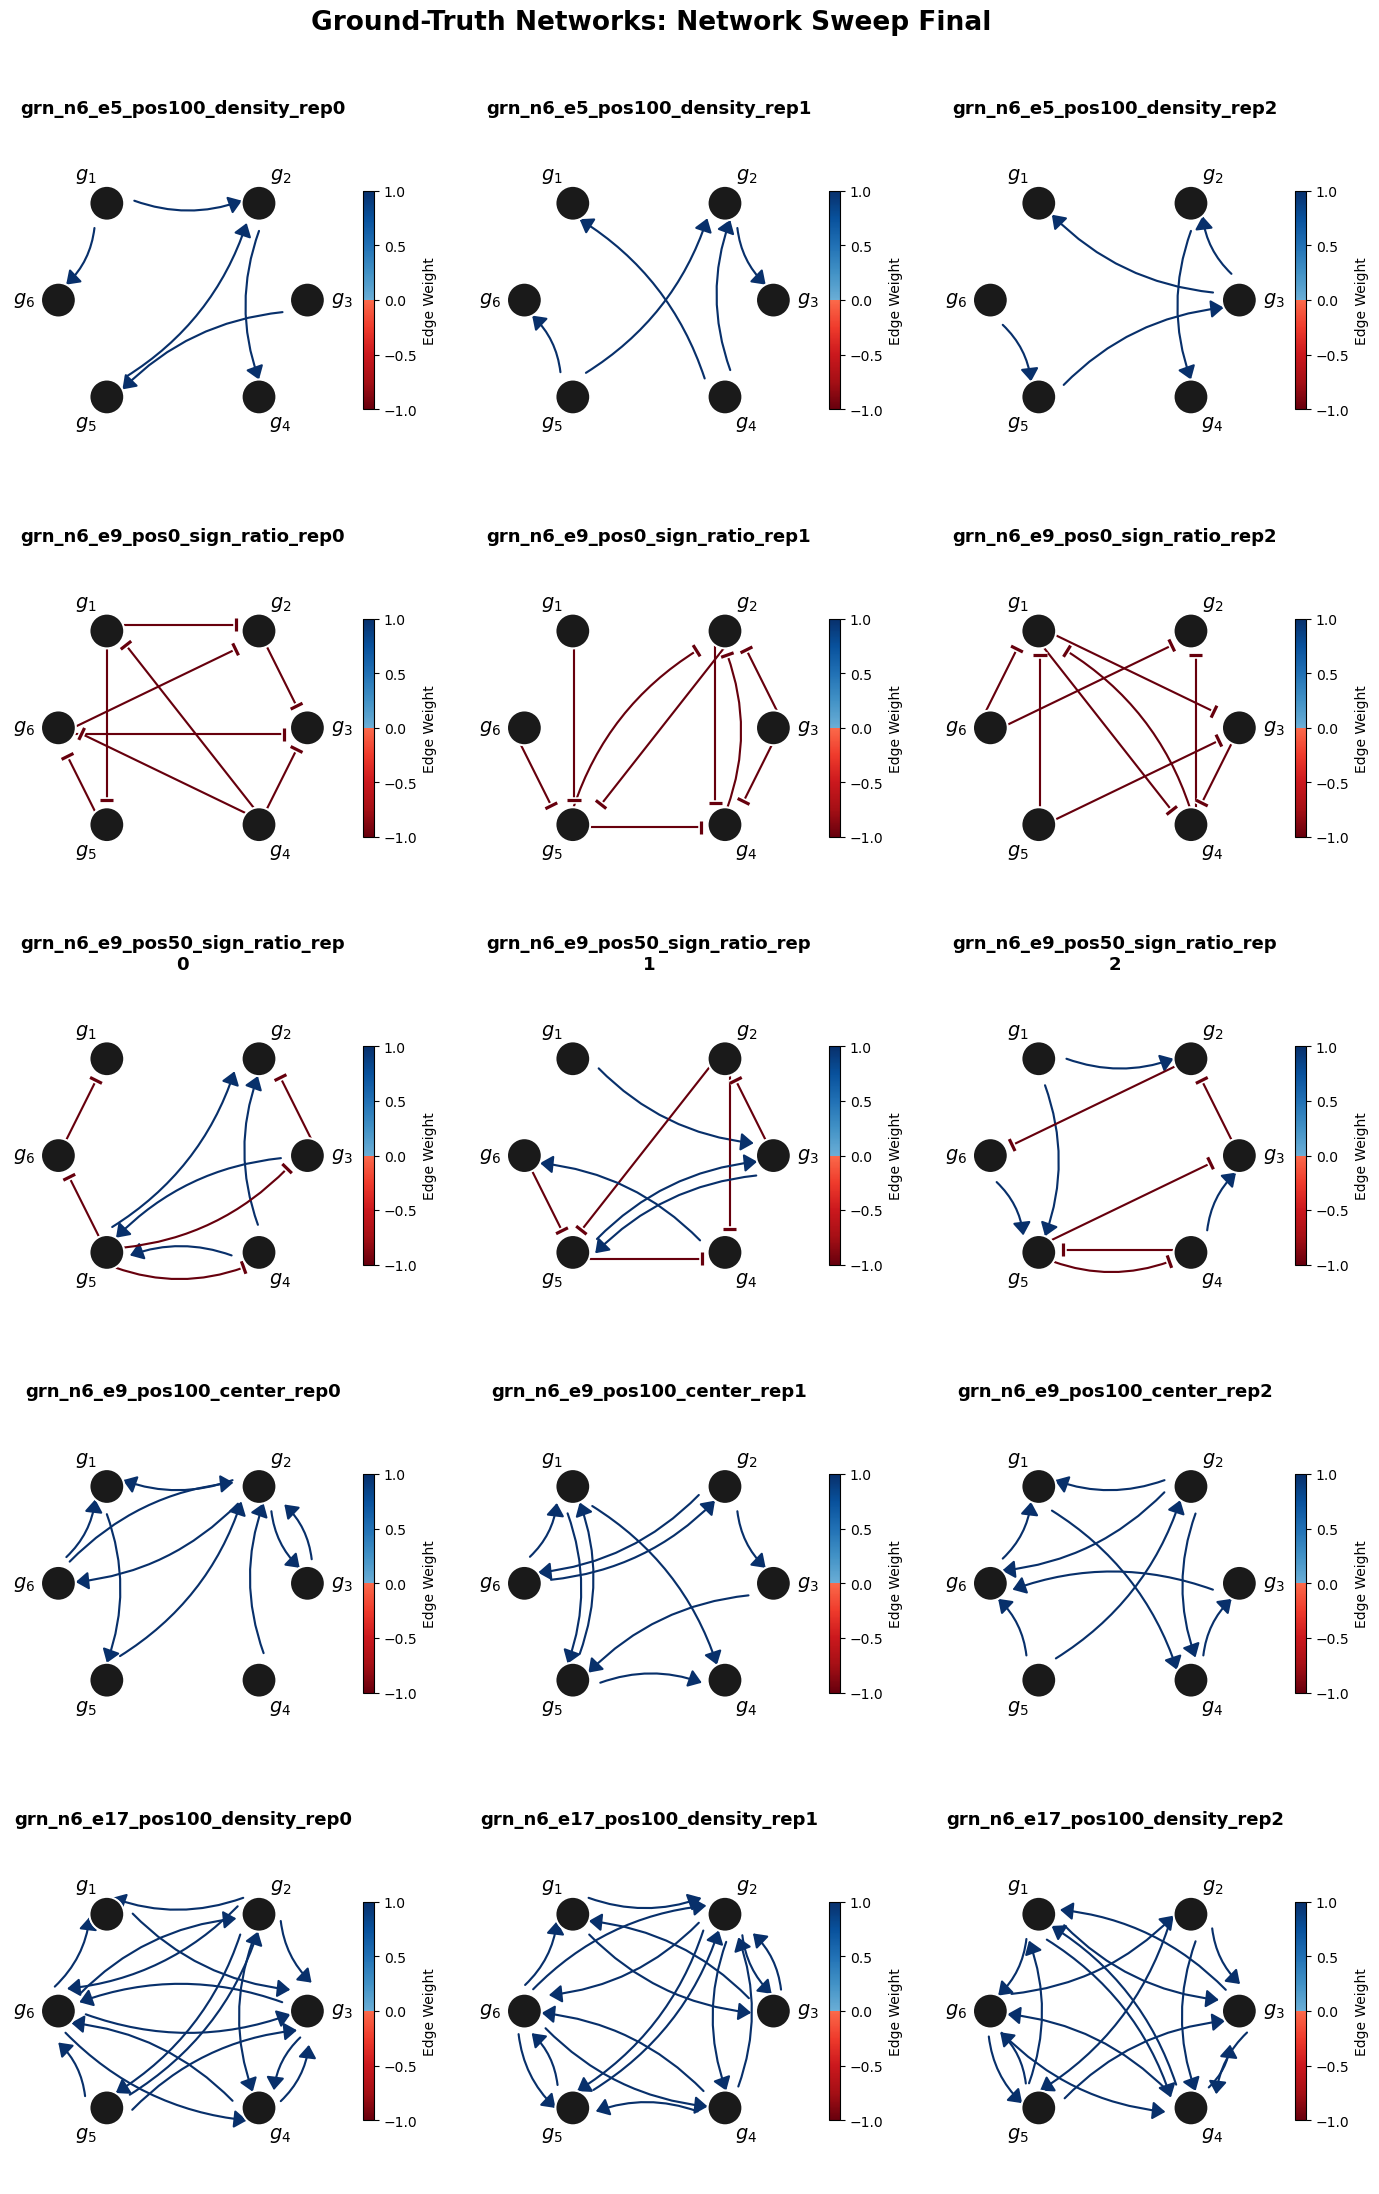

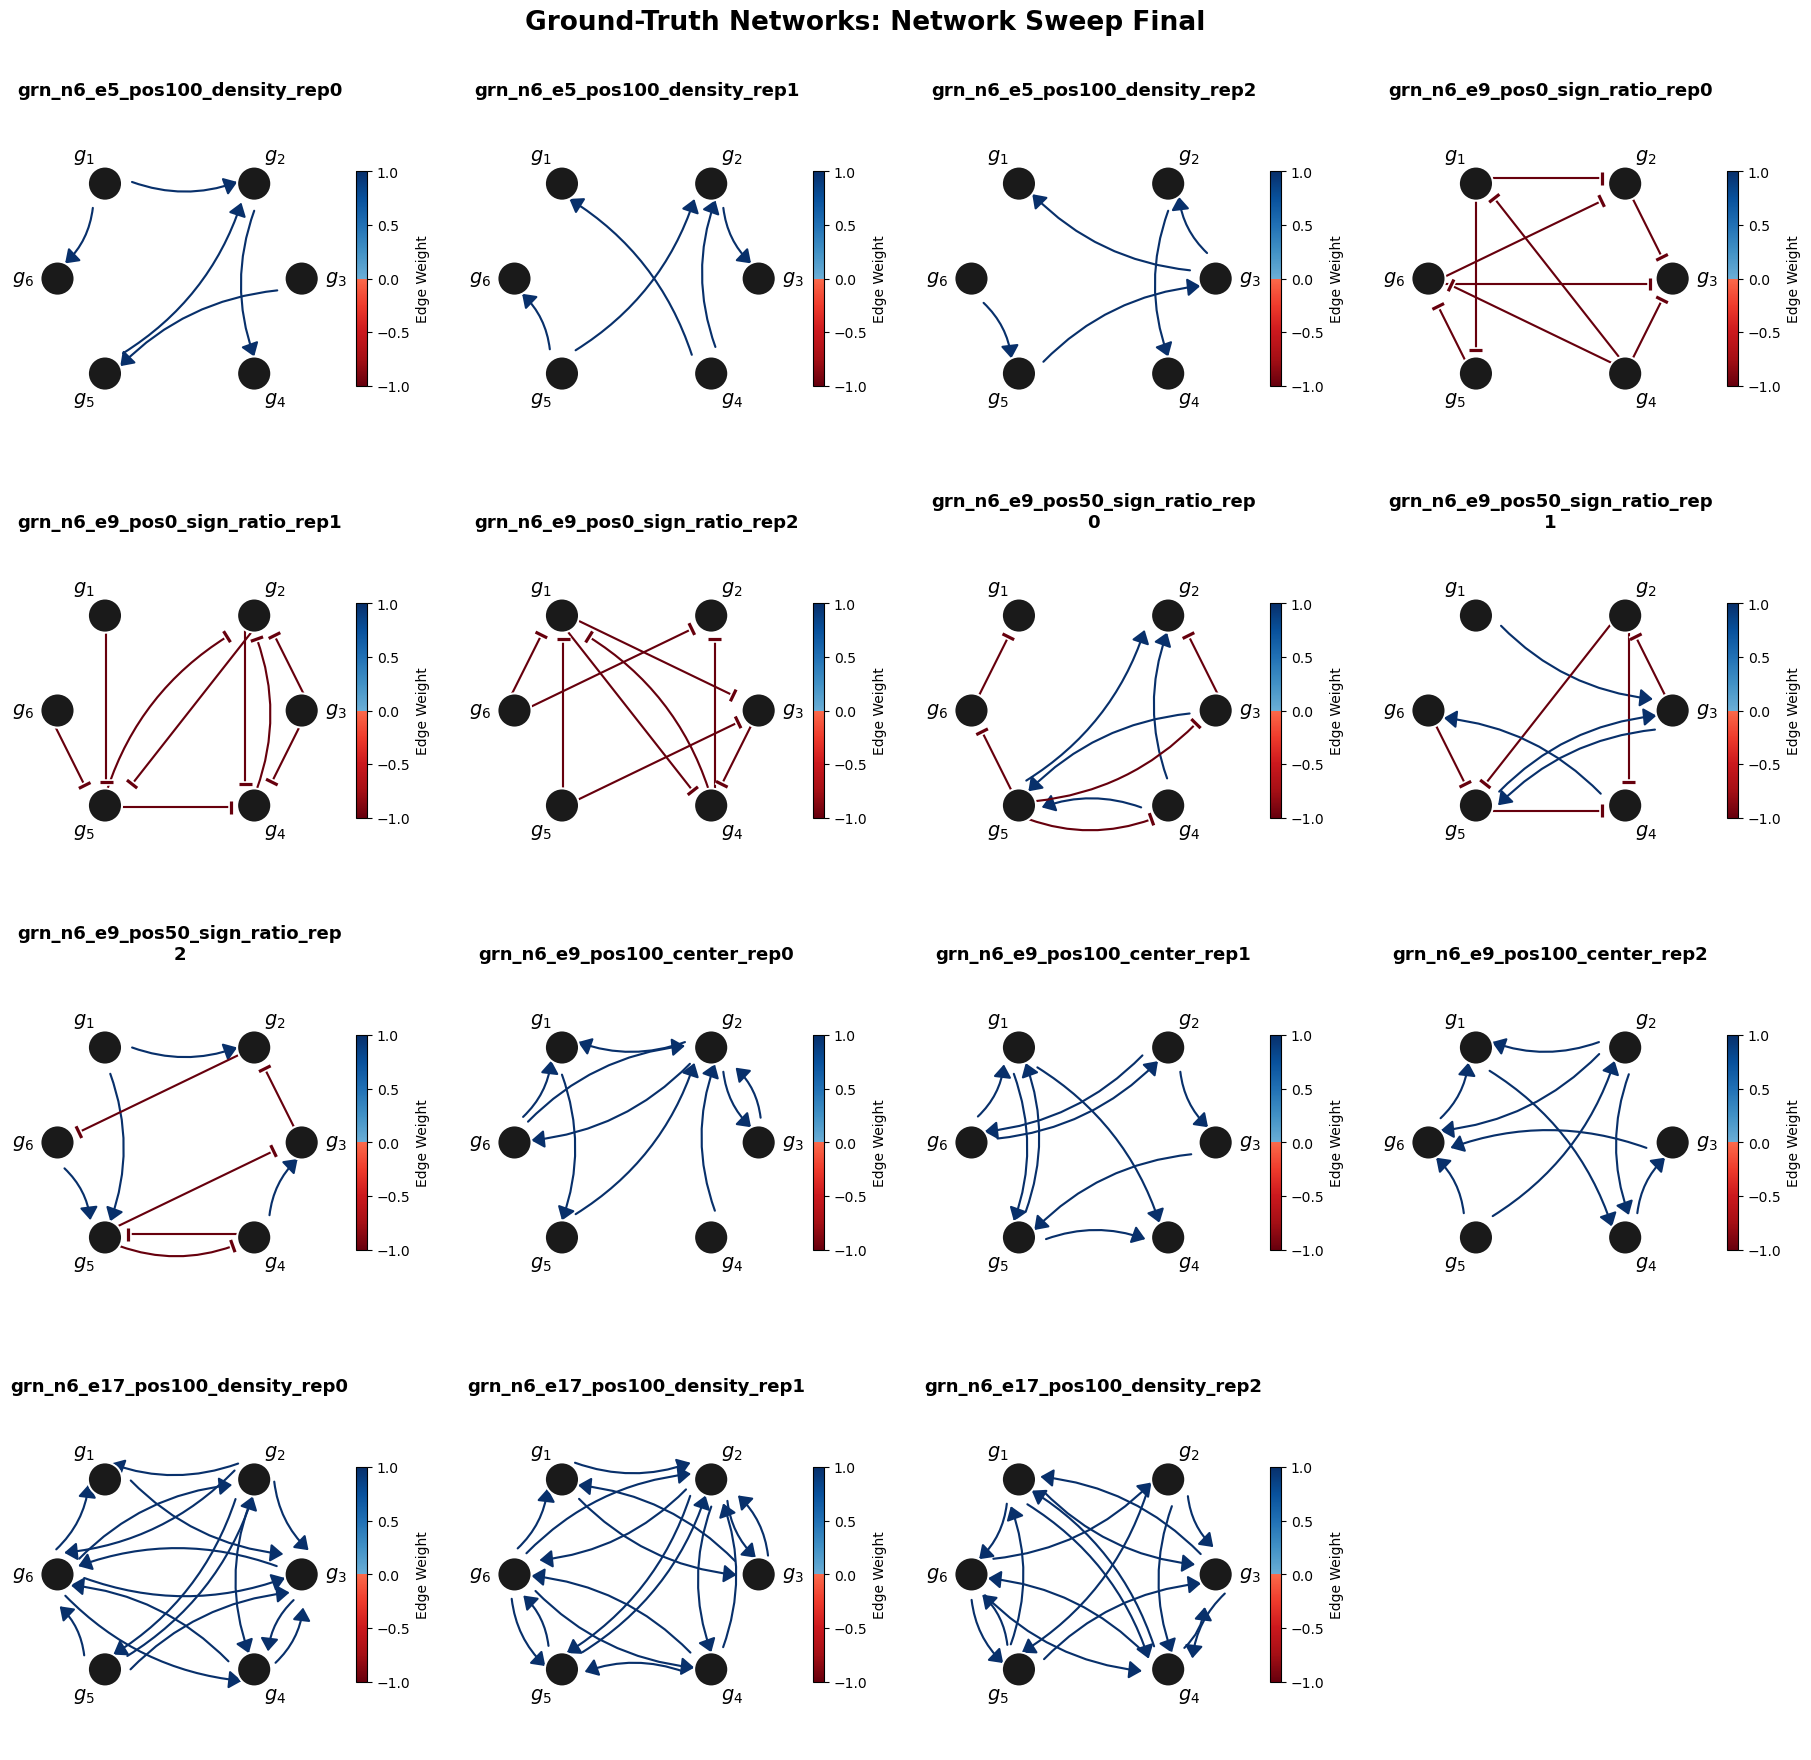


Saved PNG:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/network_sweep_final_ground_truth.png

Saved PDF:
/home/gzu5140/Keerthana_b1042/TwINFER/network_figures/network_sweep_final_ground_truth.pdf


In [12]:
import os
import re
import sys
import glob
import math
import textwrap
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 0. Paths
# ============================================================================

module_dir = "/home/gzu5140/Keerthana_b1042/TwINFER"

GT_DIR = os.path.join(
    module_dir,
    "input_data",
    "network_sweep_final",
)

INFER_DIR = os.path.join(
    module_dir,
    "analysis_data",
    "network_sweep_final",
    "network_inference",
)

output_dir = os.path.join(
    module_dir,
    "network_figures",
)

os.makedirs(output_dir, exist_ok=True)

N_GENES = 6

# ============================================================================
# 1. Reload plotting module
# ============================================================================

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

sys.path.insert(0, os.path.join(module_dir, "code", "TwINFER", "synthetic_network_analysis"))

importlib.invalidate_caches()

import grn_plot_spread_v2
importlib.reload(grn_plot_spread_v2)

from grn_plot_spread_v2 import plot_grn as plot_grn_spread

print("Loaded plotting module from:")
print(grn_plot_spread_v2.__file__)
print("plot_grn signature:")
print(inspect.signature(plot_grn_spread))
print("Plot module version:", grn_plot_spread_v2.__version__)

if "terminal_spread" not in inspect.signature(plot_grn_spread).parameters:
    raise RuntimeError(
        "The loaded grn_plot_spread_v2.py is an old version without "
        "terminal_spread. Replace the file shown above and rerun."
    )

# ============================================================================
# 2. Helpers -- identify the unique network_sweep_final configs that were
#    actually run through network inference, and load their ground truth.
# ============================================================================

CONFIG_RE = re.compile(r"^e(\d+)_pos(\d+)_(density|sign_ratio|center)_rep(\d+)_rep(\d+)_")


def parse_config(fname):
    m = CONFIG_RE.match(os.path.basename(fname))
    if not m:
        return None
    e, pos, typ, netrep, simrep = m.groups()
    return dict(e=int(e), pos=int(pos), type=typ, netrep=int(netrep), simrep=int(simrep))


def nice_title(e, pos, typ, netrep):
    return f"grn_n6_e{e}_pos{pos}_{typ}_rep{netrep}"


def load_ground_truth(name):
    path = os.path.join(GT_DIR, f"{name}.txt")
    matrix = np.loadtxt(path, delimiter=",")
    return np.asarray(matrix, dtype=float)

# ============================================================================
# 3. Discover the unique network configs referenced by inference results
# ============================================================================

result_files = sorted(glob.glob(os.path.join(INFER_DIR, "*_all_results.json")))

if not result_files:
    raise FileNotFoundError(f"No *_all_results.json files found in:\n{INFER_DIR}")

configs = set()
for file_path in result_files:
    parsed = parse_config(file_path)
    if parsed is None:
        continue
    configs.add((parsed["e"], parsed["pos"], parsed["type"], parsed["netrep"]))

configs = sorted(configs)
names = [nice_title(*config) for config in configs]

n_networks = len(names)

print(f"\nUnique network_sweep_final configs with inference results: {n_networks}")

# ============================================================================
# 4. Fixed node layout (6-gene hexagon, matching the rest of this notebook)
# ============================================================================

fixed_pos = {
    0: np.array([0.28, 0.78]),  # g1: upper-left
    1: np.array([0.72, 0.78]),  # g2: upper-right
    2: np.array([0.86, 0.50]),  # g3: right
    3: np.array([0.72, 0.22]),  # g4: lower-right
    4: np.array([0.28, 0.22]),  # g5: lower-left
    5: np.array([0.14, 0.50]),  # g6: left
}

node_labels = [f"$g_{{{gene + 1}}}$" for gene in range(N_GENES)]

# ============================================================================
# 5. Subplot grid
# ============================================================================

n_cols = 3
n_rows = -(-n_networks // n_cols)
panel_size = 4.5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(panel_size * n_cols, panel_size * n_rows),
    squeeze=False,
)
axes_flat = axes.flatten()

# ============================================================================
# 6. Plot every network
# ============================================================================

for index, name in enumerate(names):
    ax = axes_flat[index]

    wrapped_title = "\n".join(
        textwrap.wrap(
            name,
            width=30,
            break_long_words=True,
            break_on_hyphens=True,
        )
    )

    print(f"Plotting [{index + 1}/{n_networks}]: {name}")

    try:
        matrix = load_ground_truth(name)

        plot_grn_spread(
            matrix,
            node_labels=node_labels,
            title=wrapped_title,
            ax=ax,
            fixed_pos=fixed_pos,
            show_colorbar=True,
            font_size=11,
            terminal_spread=1.2,
            terminal_angle_tolerance=1.10,
            reciprocal_separation=0.70,
            max_shift_fraction=0.95,
            vmin=-1,
            vmax=1,
        )

        # Keep every panel in exactly the same coordinate range.
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.axis("off")

    except Exception as error:
        ax.clear()
        ax.axis("off")

        ax.text(
            0.5,
            0.5,
            (
                f"Plot failed\n"
                f"{name}\n\n"
                f"{type(error).__name__}: {error}"
            ),
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )

        print(f"Plot failed for {name}: {error}")

# ============================================================================
# 7. Hide unused panels
# ============================================================================

for index in range(n_networks, len(axes_flat)):
    axes_flat[index].axis("off")

# ============================================================================
# 8. Final formatting
# ============================================================================

fig.suptitle(
    "Ground-Truth Networks: Network Sweep Final",
    fontsize=19,
    fontweight="bold",
    y=0.992,
)

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    bottom=0.025,
    top=0.94,
    wspace=0.28,
    hspace=0.23,
)

# ============================================================================
# 9. Save
# ============================================================================

output_png = os.path.join(
    output_dir,
    "network_sweep_final_ground_truth.png",
)

output_pdf = os.path.join(
    output_dir,
    "network_sweep_final_ground_truth.pdf",
)
import os
import re
import sys
import glob
import math
import textwrap
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 0. Paths
# ============================================================================

module_dir = "/home/gzu5140/Keerthana_b1042/TwINFER"

GT_DIR = os.path.join(
    module_dir,
    "input_data",
    "network_sweep_final",
)

INFER_DIR = os.path.join(
    module_dir,
    "analysis_data",
    "network_sweep_final",
    "network_inference",
)

output_dir = os.path.join(
    module_dir,
    "network_figures",
)

os.makedirs(output_dir, exist_ok=True)

N_GENES = 6

# ============================================================================
# 1. Reload plotting module
# ============================================================================

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

sys.path.insert(0, os.path.join(module_dir, "code", "TwINFER", "synthetic_network_analysis"))

importlib.invalidate_caches()

import grn_plot_spread_v2
importlib.reload(grn_plot_spread_v2)

from grn_plot_spread_v2 import plot_grn as plot_grn_spread

print("Loaded plotting module from:")
print(grn_plot_spread_v2.__file__)
print("plot_grn signature:")
print(inspect.signature(plot_grn_spread))
print("Plot module version:", grn_plot_spread_v2.__version__)

if "terminal_spread" not in inspect.signature(plot_grn_spread).parameters:
    raise RuntimeError(
        "The loaded grn_plot_spread_v2.py is an old version without "
        "terminal_spread. Replace the file shown above and rerun."
    )

# ============================================================================
# 2. Helpers -- identify the unique network_sweep_final configs that were
#    actually run through network inference, and load their ground truth.
# ============================================================================

CONFIG_RE = re.compile(r"^e(\d+)_pos(\d+)_(density|sign_ratio|center)_rep(\d+)_rep(\d+)_")


def parse_config(fname):
    m = CONFIG_RE.match(os.path.basename(fname))
    if not m:
        return None
    e, pos, typ, netrep, simrep = m.groups()
    return dict(e=int(e), pos=int(pos), type=typ, netrep=int(netrep), simrep=int(simrep))


def nice_title(e, pos, typ, netrep):
    return f"grn_n6_e{e}_pos{pos}_{typ}_rep{netrep}"


def load_ground_truth(name):
    path = os.path.join(GT_DIR, f"{name}.txt")
    matrix = np.loadtxt(path, delimiter=",")
    return np.asarray(matrix, dtype=float)

# ============================================================================
# 3. Discover the unique network configs referenced by inference results
# ============================================================================

result_files = sorted(glob.glob(os.path.join(INFER_DIR, "*_all_results.json")))

if not result_files:
    raise FileNotFoundError(f"No *_all_results.json files found in:\n{INFER_DIR}")

configs = set()
for file_path in result_files:
    parsed = parse_config(file_path)
    if parsed is None:
        continue
    configs.add((parsed["e"], parsed["pos"], parsed["type"], parsed["netrep"]))

configs = sorted(configs)
names = [nice_title(*config) for config in configs]

n_networks = len(names)

print(f"\nUnique network_sweep_final configs with inference results: {n_networks}")

# ============================================================================
# 4. Fixed node layout (6-gene hexagon, matching the rest of this notebook)
# ============================================================================

fixed_pos = {
    0: np.array([0.28, 0.78]),  # g1: upper-left
    1: np.array([0.72, 0.78]),  # g2: upper-right
    2: np.array([0.86, 0.50]),  # g3: right
    3: np.array([0.72, 0.22]),  # g4: lower-right
    4: np.array([0.28, 0.22]),  # g5: lower-left
    5: np.array([0.14, 0.50]),  # g6: left
}

node_labels = [f"$g_{{{gene + 1}}}$" for gene in range(N_GENES)]

# ============================================================================
# 5. Subplot grid
# ============================================================================

n_cols = 4
n_rows = -(-n_networks // n_cols)
panel_size = 4.5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(panel_size * n_cols, panel_size * n_rows),
    squeeze=False,
)
axes_flat = axes.flatten()

# ============================================================================
# 6. Plot every network
# ============================================================================

for index, name in enumerate(names):
    ax = axes_flat[index]

    wrapped_title = "\n".join(
        textwrap.wrap(
            name,
            width=30,
            break_long_words=True,
            break_on_hyphens=True,
        )
    )

    print(f"Plotting [{index + 1}/{n_networks}]: {name}")

    try:
        matrix = load_ground_truth(name)

        plot_grn_spread(
            matrix,
            node_labels=node_labels,
            title=wrapped_title,
            ax=ax,
            fixed_pos=fixed_pos,
            show_colorbar=True,
            font_size=11,
            terminal_spread=1.1,
            terminal_angle_tolerance=1.10,
            reciprocal_separation=0.70,
            max_shift_fraction=1,
            vmin=-1,
            vmax=1,
        )

        # Keep every panel in exactly the same coordinate range.
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.axis("off")

    except Exception as error:
        ax.clear()
        ax.axis("off")

        ax.text(
            0.5,
            0.5,
            (
                f"Plot failed\n"
                f"{name}\n\n"
                f"{type(error).__name__}: {error}"
            ),
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )

        print(f"Plot failed for {name}: {error}")

# ============================================================================
# 7. Hide unused panels
# ============================================================================

for index in range(n_networks, len(axes_flat)):
    axes_flat[index].axis("off")

# ============================================================================
# 8. Final formatting
# ============================================================================

fig.suptitle(
    "Ground-Truth Networks: Network Sweep Final",
    fontsize=19,
    fontweight="bold",
    y=0.992,
)

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    bottom=0.025,
    top=0.94,
    wspace=0.28,
    hspace=0.23,
)

# ============================================================================
# 9. Save
# ============================================================================

output_png = os.path.join(
    output_dir,
    "network_sweep_final_ground_truth.png",
)

output_pdf = os.path.join(
    output_dir,
    "network_sweep_final_ground_truth.pdf",
)

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved PNG:")
print(output_png)

print("\nSaved PDF:")
print(output_pdf)

# ============================================================================
# 10. Display
# ============================================================================

plt.show()
plt.close(fig)
fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

print("\nSaved PNG:")
print(output_png)

print("\nSaved PDF:")
print(output_pdf)

# ============================================================================
# 10. Display
# ============================================================================

plt.show()
plt.close(fig)
